
# Proyecto Colaborativo: Análisis Exploratorio y Modelado Estadístico

## Introducción
El objetivo de este proyecto es realizar un análisis integral de un conjunto de datos para extraer conclusiones y responder a una serie de preguntas de investigación planteadas por el propio equipo. El trabajo abarca desde el procesamiento técnico de la información hasta la validación estadística de hipótesis y el modelado predictivo.

## Fases del Proyecto

**1. Limpieza y Análisis Exploratorio de Datos (EDA)**

Esta fase se abordará como un proceso iterativo en el que la comprensión de los datos y su depuración avanzan en paralelo. El objetivo es transformar el *dataset* en bruto en una fuente de información fiable y estructurada. El equipo deberá trabajar los siguientes puntos:

*   **Limpieza Técnica y de Calidad:** Realizar el tipado correcto de las variables (conversión de *strings* a números, manejo de fechas, etc.) y asegurar la integridad de la información mediante la identificación y tratamiento de valores nulos, registros duplicados e inconsistencias lógicas.
*   **Análisis Univariado y Multivariado:** Realizar un estudio tanto individual de las variables (distribuciones, medidas de tendencia central y dispersión) como de las relaciones entre ellas (correlaciones, tablas de contingencia y comparativas). Este análisis debe aplicarse de forma general en la exploración inicial y de forma específica en la **fase 2**, al profundizar en los objetivos del proyecto.
*   **Gestión de Outliers:** Identificar valores atípicos mediante métodos estadísticos o visuales y justificar razonadamente su tratamiento.
*   **Feature Engineering:** Crear nuevas variables derivadas que aporten valor al estudio o transformar las existentes para facilitar el posterior análisis estadístico y modelado.
*   **Visualización:** Utilizar gráficos adecuados (histogramas, diagramas de dispersión, *boxplots*, mapas de calor, etc.) para detectar patrones y anomalías, así como para sustentar las respuestas a las preguntas planteadas en la **fase 2**.


### Limpieza Técnica y de Calidad
---
*   **Imports para el proyecto :** Se realiza la apertura de los imports.
*   **Verificacion del Dataset :** Hacemos la verificacion que los datos estan Ok en la apertura y utilizamos la funciones `mostrar_resumen_info`, `mostrar_valores_unicos` ,`resumen_univariado_numerico_cuantitativo`,  para ver que las columnas y tipos de datos de las columnas son correctos y agilizar la limpieza

In [56]:
# Cosas que no hemos instalado en el curso pero que va bien para ver los datos en un xlsx.
# pip install openpyxl
# esta libreria la utiliza pnadas para exportar a xlsx, no es necesario hacer import con import pandas as pd, es suficiente.

#Imports necesarios para el proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

from IPython.display import Markdown, display  # prueba Markdown para display

from typing import cast

from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LinearRegression

# Métricas
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

In [57]:
# Funciones para el analisis de dataset

# Funcion para mostrar un resumen de la informacion del DataFrame, incluyendo tipo de datos, valores nulos, estadisticas descriptivas, etc.
def mostrar_resumen_info (dataframe: pd.DataFrame)-> pd.DataFrame:
    df_resumen: pd.DataFrame = pd.DataFrame({
        "columna":      dataframe.columns,
        "dtype":        dataframe.dtypes.astype(str).values,
        "duplicados":   dataframe.duplicated(keep=False).sum(),
        "total":        dataframe.shape[0],
        "no_nulos":     dataframe.notna().sum().values,
        "nulos":        dataframe.isna().sum().values,
        "pct_nulos":    (dataframe.isna().sum() / len(dataframe) * 100).round(2).values,
        "valor_unicos": dataframe.nunique().values,
        "count":        [dataframe[columna].count()        if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "max":          [dataframe[columna].max()          if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "min":          [dataframe[columna].min()          if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "media":        [dataframe[columna].mean()         if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "mediana":      [dataframe[columna].median()       if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "des_estandar": [dataframe[columna].std()          if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "25%_cuartil":  [dataframe[columna].quantile(0.25) if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "50%_cuartil":  [dataframe[columna].quantile(0.50) if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns],
        "75%_cuartil":  [dataframe[columna].quantile(0.75) if dataframe.dtypes[columna] in [np.int64, np.float64,np.int32,np.float32] else None for columna in dataframe.columns]
    })
    return df_resumen

# Funcion para mostrar los datos de valores unicos de cada columna que no pase de un valor maximo.
def mostrar_valores_unicos(dataframe: pd.DataFrame, max: int) -> pd.DataFrame:
    filas: list[dict] = [] # utilizamos un diccionario para almacenar los datos de cada fila, con claves "columna" y "valor"
    for columna in dataframe.columns:
        valores_unicos_columna: list[str] = dataframe[columna].unique()
        if len(valores_unicos_columna) <= max:
            for campo in valores_unicos_columna:
                filas.append({
                    "columna": columna,
                    "valor": campo
                })
    df_valores_unicos = pd.DataFrame(filas) # creamos un dataframe con el diccionario filas, con columnas "columna" y "valor"
    return df_valores_unicos 

# Funcion para mostar un resumen de las columnas numerricas cuantitativas.
def resumen_univariado_numerico_cuantitativo(dataframe: pd.DataFrame, lista_columnas: list[str]) -> pd.DataFrame:
    filas: list[dict] = []
    for columna in lista_columnas:
        if columna in dataframe.columns:
            fila: dict = {
                "columna": columna,
                "mean"   : dataframe[columna].mean(),
                "median" : dataframe[columna].median(),
                "std"    : dataframe[columna].std(),
                "skew"   : dataframe[columna].skew(),
                "kurt"   : dataframe[columna].kurtosis()
            }
            filas.append(fila)
    df_resumen_univariado_numerico_cuantitativo: pd.DataFrame = pd.DataFrame(filas)
    return df_resumen_univariado_numerico_cuantitativo   

In [58]:
# Apertura de los dos datasets

# Apertura del dataset 1.
try:
    df_idealista18_1: pd.DataFrame = pd.read_csv(filepath_or_buffer = "Idealista/idealista18_1.csv", sep = ",")
except FileNotFoundError:
    print("Error: El archivo Idealista/idealista18_1.csv no se encontró.")
except Exception as e:
    print(f"Error al abrir el archivo: {e}")           


# Apertura del dataset 2.
try:
    df_idealista18_2: pd.DataFrame = pd.read_csv(filepath_or_buffer = "Idealista/idealista18_2.csv", sep = ",")
except FileNotFoundError:
    print("Error: El archivo Idealista/idealista18_2.csv no se encontró.")
except Exception as e:
    print(f"Error al abrir el archivo: {e}")           



In [59]:
# Verificacion que los datasets que columas tienen para ver como unirlos posteriormente.
lista_columnas_idealista_1: list[str] = list(df_idealista18_1.columns)
lista_columnas_idealista_2: list[str] = list(df_idealista18_2.columns)

# print("")
# print ( "-> Columnas de los datasets:")
# print ("-"*815)
# print (f" -> Idealista 1 columnas: {lista_columnas_idealista_1}")
# print (f" -> Idealista 2 columnas: {lista_columnas_idealista_2}")
# print ("-"*815)
# print("")


md = f"""
---
### 📂 Columnas de los datasets
---

**Idealista 1 columnas:** {", ".join(lista_columnas_idealista_1)}  

**Idealista 2 columnas:** {", ".join(lista_columnas_idealista_2)}
"""

display(Markdown(md))


---
### 📂 Columnas de los datasets
---

**Idealista 1 columnas:** ASSETID, PERIOD, PRICE, UNITPRICE, ADTYPOLOGYID, ADOPERATIONID, CONSTRUCTEDAREA, ROOMNUMBER, BATHNUMBER, HASTERRACE, HASLIFT, HASAIRCONDITIONING, AMENITYID, HASPARKINGSPACE, ISPARKINGSPACEINCLUDEDINPRICE, PARKINGSPACEPRICE, HASNORTHORIENTATION, HASSOUTHORIENTATION, HASEASTORIENTATION, HASWESTORIENTATION, HASBOXROOM, HASWARDROBE, HASSWIMMINGPOOL, HASDOORMAN, HASGARDEN, ISDUPLEX, ISSTUDIO, ISINTOPFLOOR, CONSTRUCTIONYEAR, FLOORCLEAN, FLATLOCATIONID, CADCONSTRUCTIONYEAR, CADMAXBUILDINGFLOOR, CADDWELLINGCOUNT, CADASTRALQUALITYID, BUILTTYPEID_1, BUILTTYPEID_2, BUILTTYPEID_3, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO, DISTANCE_TO_STREET, LONGITUDE, LATITUDE, CITYNAME, ADTYPOLOGY, ADOPERATION  

**Idealista 2 columnas:** ASSETID, PERIOD, PRICE, UNITPRICE, ADTYPOLOGYID, ADOPERATIONID, CONSTRUCTEDAREA, ROOMNUMBER, BATHNUMBER, HASTERRACE, HASLIFT, HASAIRCONDITIONING, AMENITYID, HASPARKINGSPACE, ISPARKINGSPACEINCLUDEDINPRICE, PARKINGSPACEPRICE, HASNORTHORIENTATION, HASSOUTHORIENTATION, HASEASTORIENTATION, HASWESTORIENTATION, HASBOXROOM, HASWARDROBE, HASSWIMMINGPOOL, HASDOORMAN, HASGARDEN, ISDUPLEX, ISSTUDIO, ISINTOPFLOOR, CONSTRUCTIONYEAR, FLOORCLEAN, FLATLOCATIONID, CADCONSTRUCTIONYEAR, CADMAXBUILDINGFLOOR, CADDWELLINGCOUNT, CADASTRALQUALITYID, BUILTTYPEID_1, BUILTTYPEID_2, BUILTTYPEID_3, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO, DISTANCE_TO_STREET, LONGITUDE, LATITUDE, CITYNAME, ADTYPOLOGY, ADOPERATION


In [60]:
# Unificamos los datasets porque tienen las mismas columnas.
df_idealista: pd.DataFrame = pd.concat([df_idealista18_1, df_idealista18_2], axis = 0, ignore_index = True) #axis indica la direccion de la concatenacion, ignore_index=True resetea los indices.

df_idealista.head(10)

,ASSETID,PERIOD,PRICE,UNITPRICE,ADTYPOLOGYID,ADOPERATIONID,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,...,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,ADTYPOLOGY,ADOPERATION
0,A12377633511549727658,201812,109000,1730.158730,HOME,SALE,63,3,1,1,...,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,HOME,SALE
1,A7691539882862170545,201809,155000,2384.615385,HOME,SALE,65,2,1,0,...,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,HOME,SALE
2,A4316988685482817826,201809,158000,2025.641026,HOME,SALE,78,3,1,1,...,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,HOME,SALE
3,A12032801997263349694,201812,126000,1680.000000,HOME,SALE,75,3,1,1,...,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,HOME,SALE
4,A16032891972289007994,201803,184000,1840.000000,HOME,SALE,100,3,2,1,...,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,HOME,SALE
5,A557535983324294560,201812,123000,1537.500000,HOME,SALE,80,2,1,0,...,0,1,4.181523,0.321047,2.876406,-3.727624,40.383703,Madrid,HOME,SALE
6,A9961453812407342401,201809,113000,1614.285714,HOME,SALE,70,2,1,1,...,0,1,4.182505,0.296434,2.819628,-3.726784,40.383348,Madrid,HOME,SALE
7,A16410429174834418672,201812,88000,1353.846154,HOME,SALE,65,3,1,0,...,0,1,4.619444,0.264340,3.257273,-3.731019,40.380645,Madrid,HOME,SALE
8,A2168623657766044008,201803,220000,2750.000000,HOME,SALE,80,3,1,1,...,0,1,4.501851,0.058095,2.990493,-3.727506,40.380406,Madrid,HOME,SALE
9,A7390573721374673939,201812,318000,2971.962617,HOME,SALE,107,3,2,1,...,0,1,5.171105,0.627763,3.338619,-3.727317,40.373732,Madrid,HOME,SALE


In [ ]:
# Exportar el dataset a un xlsx para ver el contenido .
try:
    df_idealista.to_excel("Idealista/Xlsx/idealista_completo.xlsx", index=False) # index=False para no incluir la columna de indices en el archivo exportado.   
    print("Archivo exportado exitosamente a Idealista/Xlsx/idealista_completo.xlsx")
except Exception as e:
    print(f"Error al exportar el archivo: {e}") 


In [61]:
# Con la funcion mostrar_resumen_info mostramos un resumen del dataset.
df_resumen: pd.DataFrame = mostrar_resumen_info(df_idealista)
df_resumen


,columna,dtype,duplicados,total,no_nulos,nulos,pct_nulos,valor_unicos,count,max,min,media,mediana,des_estandar,25%_cuartil,50%_cuartil,75%_cuartil
0,ASSETID,str,10000,194923,194923,0,0.00,149923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PERIOD,int64,10000,194923,194923,0,0.00,4,194923.0,2.018120e+05,201803.000000,201808.376692,201809.000000,3.710309,201803.000000,201809.000000,201812.000000
2,PRICE,int64,10000,194923,194923,0,0.00,2864,194923.0,8.133000e+06,20000.000000,358970.347265,259000.000000,349991.800702,159000.000000,259000.000000,426000.000000
3,UNITPRICE,float64,10000,194923,194923,0,0.00,44172,194923.0,9.997561e+03,480.686695,3428.427408,3325.000000,1639.860325,2066.666667,3325.000000,4531.645570
4,ADTYPOLOGYID,str,10000,194923,194923,0,0.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ADOPERATIONID,str,10000,194923,194923,0,0.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CONSTRUCTEDAREA,int64,10000,194923,194923,0,0.00,589,194923.0,9.850000e+02,21.000000,100.513085,86.000000,59.470246,66.000000,86.000000,115.000000
7,ROOMNUMBER,int64,10000,194923,194923,0,0.00,23,194923.0,9.300000e+01,0.000000,2.750722,3.000000,1.194734,2.000000,3.000000,3.000000
8,BATHNUMBER,int64,10000,194923,194923,0,0.00,18,194923.0,2.000000e+01,0.000000,1.561191,1.000000,0.768198,1.000000,1.000000,2.000000
9,HASTERRACE,int64,10000,194923,194923,0,0.00,2,194923.0,1.000000e+00,0.000000,0.330531,0.000000,0.470405,0.000000,0.000000,1.000000


In [62]:
# Limpiesa de datos:

# Parece que nos dan 10_000 filas con datos duplicados.
df_idealista.duplicated(keep = False).sum() # keep = False marca como duplicados todas las filas que tienen duplicados. 

# Mostar 10 filas duplicadas para ver en el xlsx.
df_idealista[df_idealista.duplicated(keep = False)].head(10)



,ASSETID,PERIOD,PRICE,UNITPRICE,ADTYPOLOGYID,ADOPERATIONID,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,...,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME,ADTYPOLOGY,ADOPERATION
0,A12377633511549727658,201812,109000,1730.158730,HOME,SALE,63,3,1,1,...,0,1,4.166611,0.313529,2.814425,-3.726785,40.383510,Madrid,HOME,SALE
1,A7691539882862170545,201809,155000,2384.615385,HOME,SALE,65,2,1,0,...,0,1,4.477237,0.109565,2.934052,-3.726764,40.380375,Madrid,HOME,SALE
2,A4316988685482817826,201809,158000,2025.641026,HOME,SALE,78,3,1,1,...,0,1,4.294954,0.217547,2.788894,-3.725683,40.381796,Madrid,HOME,SALE
3,A12032801997263349694,201812,126000,1680.000000,HOME,SALE,75,3,1,1,...,0,1,4.861939,0.355738,3.455590,-3.732578,40.378816,Madrid,HOME,SALE
4,A16032891972289007994,201803,184000,1840.000000,HOME,SALE,100,3,2,1,...,0,1,4.786463,0.395206,3.399424,-3.732196,40.379431,Madrid,HOME,SALE
5,A557535983324294560,201812,123000,1537.500000,HOME,SALE,80,2,1,0,...,0,1,4.181523,0.321047,2.876406,-3.727624,40.383703,Madrid,HOME,SALE
6,A9961453812407342401,201809,113000,1614.285714,HOME,SALE,70,2,1,1,...,0,1,4.182505,0.296434,2.819628,-3.726784,40.383348,Madrid,HOME,SALE
7,A16410429174834418672,201812,88000,1353.846154,HOME,SALE,65,3,1,0,...,0,1,4.619444,0.264340,3.257273,-3.731019,40.380645,Madrid,HOME,SALE
8,A2168623657766044008,201803,220000,2750.000000,HOME,SALE,80,3,1,1,...,0,1,4.501851,0.058095,2.990493,-3.727506,40.380406,Madrid,HOME,SALE
9,A7390573721374673939,201812,318000,2971.962617,HOME,SALE,107,3,2,1,...,0,1,5.171105,0.627763,3.338619,-3.727317,40.373732,Madrid,HOME,SALE


In [63]:
# Quitamos los duplicados y dejamos el dataset limpio para trabajar con el.

# # Total filas dataset original.
# print("-"*50)
# print(f"--> Total filas df_idealista [{df_idealista.shape[0]}]")
# print("-"*50)
# print("")

df_idealista_limpio: pd.DataFrame = df_idealista.drop_duplicates()

# # Total filas dataset limpio.
# print("-"*50)
# print(f"--> Total filas df_idealista_limpio [{df_idealista_limpio.shape[0]}]")
# print("-"*50)
# print("")

md = f"""
---
```text
➡️ {'Total filas df_idealista ['} {df_idealista.shape[0]} ]
➡️ {'Total filas df_idealista_limpio ['} {df_idealista_limpio.shape[0]} ]
```
---
"""

display(Markdown(md))


---
```text
➡️ Total filas df_idealista [ 194923 ]
➡️ Total filas df_idealista_limpio [ 189923 ]
```
---


In [64]:
# Volvemos a mostrar un resumen del dataset limpio para ver como ha quedado.
df_resumen_limpio: pd.DataFrame = mostrar_resumen_info(df_idealista_limpio)
df_resumen_limpio

,columna,dtype,duplicados,total,no_nulos,nulos,pct_nulos,valor_unicos,count,max,min,media,mediana,des_estandar,25%_cuartil,50%_cuartil,75%_cuartil
0,ASSETID,str,0,189923,189923,0,0.00,149923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PERIOD,int64,0,189923,189923,0,0.00,4,189923.0,2.018120e+05,201803.000000,201808.340712,201809.000000,3.732003,201803.000000,201809.000000,201812.000000
2,PRICE,int64,0,189923,189923,0,0.00,2864,189923.0,8.133000e+06,20000.000000,361225.938933,261000.000000,351673.662275,160000.000000,261000.000000,428000.000000
3,UNITPRICE,float64,0,189923,189923,0,0.00,44172,189923.0,9.997561e+03,480.686695,3440.716847,3347.222222,1643.406877,2078.651685,3347.222222,4544.499450
4,ADTYPOLOGYID,str,0,189923,189923,0,0.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ADOPERATIONID,str,0,189923,189923,0,0.00,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CONSTRUCTEDAREA,int64,0,189923,189923,0,0.00,589,189923.0,9.850000e+02,21.000000,100.811476,86.000000,59.650332,66.000000,86.000000,116.000000
7,ROOMNUMBER,int64,0,189923,189923,0,0.00,23,189923.0,9.300000e+01,0.000000,2.758460,3.000000,1.197386,2.000000,3.000000,3.000000
8,BATHNUMBER,int64,0,189923,189923,0,0.00,18,189923.0,2.000000e+01,0.000000,1.563897,1.000000,0.769913,1.000000,1.000000,2.000000
9,HASTERRACE,int64,0,189923,189923,0,0.00,2,189923.0,1.000000e+00,0.000000,0.329254,0.000000,0.469944,0.000000,0.000000,1.000000


In [65]:
# se observa que hay columnas con un solo valor unico, lo que no aporta informacion.

# Mostramos las columnas que tiene un solo volor unico
columnas_valor_unico: list[str] = [columna for columna in df_idealista_limpio.columns if df_idealista_limpio[columna].nunique() == 1]
# print("-"*110)
# print(f"--> Columnas con un solo valor unico: {columnas_valor_unico}")
# print("-"*110)
# print("")


md = f"""
---
```text
➡️ Columnas con un solo valor unico {", ".join(columnas_valor_unico)}
```
---
"""

display(Markdown(md))

# Borramos del dataset las columnas que no tienen informacion (valor unico).
# print("-"*110)
# print(f"--> Borramos las columnas con un solo valor unico: {columnas_valor_unico}")
# print("-"*110)
# print("")

md = f"""
---
```text
❌ Borramos las columnas con un solo valor unico {", ".join(columnas_valor_unico)}
```
---
"""

display(Markdown(md))

df_idealista_limpio: pd.DataFrame  = df_idealista_limpio.drop(columns = columnas_valor_unico)

# Borramos del Dataset las columnas que no nos aporta informacion (columna : "AMENITYID") 
# print("-"*110)
# print("--> Borramos la columna que no nos aporta informacion: AMENITYID")
# print("-"*110)
# print("")

md = """
---
```text
❌ Borramos la columna que no nos aporta informacion  AMENITYID
```
---
"""

display(Markdown(md))

df_idealista_limpio = df_idealista_limpio.drop(columns=["AMENITYID"])


---
```text
➡️ Columnas con un solo valor unico ADTYPOLOGYID, ADOPERATIONID, ADTYPOLOGY, ADOPERATION
```
---



---
```text
❌ Borramos las columnas con un solo valor unico ADTYPOLOGYID, ADOPERATIONID, ADTYPOLOGY, ADOPERATION
```
---



---
```text
❌ Borramos la columna que no nos aporta informacion  AMENITYID
```
---


In [66]:
# Volvemos a mostrar un resumen del dataset limpio para ver como ha quedado.
df_resumen_limpio: pd.DataFrame = mostrar_resumen_info(df_idealista_limpio)
df_resumen_limpio

,columna,dtype,duplicados,total,no_nulos,nulos,pct_nulos,valor_unicos,count,max,min,media,mediana,des_estandar,25%_cuartil,50%_cuartil,75%_cuartil
0,ASSETID,str,0,189923,189923,0,0.00,149923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PERIOD,int64,0,189923,189923,0,0.00,4,189923.0,2.018120e+05,201803.000000,201808.340712,201809.000000,3.732003,201803.000000,201809.000000,201812.000000
2,PRICE,int64,0,189923,189923,0,0.00,2864,189923.0,8.133000e+06,20000.000000,361225.938933,261000.000000,351673.662275,160000.000000,261000.000000,428000.000000
3,UNITPRICE,float64,0,189923,189923,0,0.00,44172,189923.0,9.997561e+03,480.686695,3440.716847,3347.222222,1643.406877,2078.651685,3347.222222,4544.499450
4,CONSTRUCTEDAREA,int64,0,189923,189923,0,0.00,589,189923.0,9.850000e+02,21.000000,100.811476,86.000000,59.650332,66.000000,86.000000,116.000000
5,ROOMNUMBER,int64,0,189923,189923,0,0.00,23,189923.0,9.300000e+01,0.000000,2.758460,3.000000,1.197386,2.000000,3.000000,3.000000
6,BATHNUMBER,int64,0,189923,189923,0,0.00,18,189923.0,2.000000e+01,0.000000,1.563897,1.000000,0.769913,1.000000,1.000000,2.000000
7,HASTERRACE,int64,0,189923,189923,0,0.00,2,189923.0,1.000000e+00,0.000000,0.329254,0.000000,0.469944,0.000000,0.000000,1.000000
8,HASLIFT,int64,0,189923,189923,0,0.00,2,189923.0,1.000000e+00,0.000000,0.727642,1.000000,0.445174,0.000000,1.000000,1.000000
9,HASAIRCONDITIONING,int64,0,189923,189923,0,0.00,2,189923.0,1.000000e+00,0.000000,0.459544,0.000000,0.498362,0.000000,0.000000,1.000000


In [67]:
# Miramos los volores unicos de cada columna con la funcion mostrar_valores_unicos.
# la variable max es para que muestre solo columnas que sean menores o igual a la variable.
df_valores_unicos: pd.DataFrame = mostrar_valores_unicos(df_idealista_limpio, max = 2) 
df_valores_unicos

,columna,valor
0,HASTERRACE,1
1,HASTERRACE,0
2,HASLIFT,0
3,HASLIFT,1
4,HASAIRCONDITIONING,0
5,HASAIRCONDITIONING,1
6,HASPARKINGSPACE,0
7,HASPARKINGSPACE,1
8,ISPARKINGSPACEINCLUDEDINPRICE,0
9,ISPARKINGSPACEINCLUDEDINPRICE,1


In [77]:
lista_columnas_bool: list[str] = list(df_valores_unicos["columna"].unique())

# print("-"*380)
# print (f"--> Columnas booleanas: {lista_columnas_bool}")
# print("-"*380)
# print("")

md = f"""
---
```text
➡️ Columnas booleanas  {", ".join(lista_columnas_bool)}
```
---
"""

display(Markdown(md))



---
```text
➡️ Columnas booleanas  HASTERRACE, HASLIFT, HASAIRCONDITIONING, HASPARKINGSPACE, ISPARKINGSPACEINCLUDEDINPRICE, HASNORTHORIENTATION, HASSOUTHORIENTATION, HASEASTORIENTATION, HASWESTORIENTATION, HASBOXROOM, HASWARDROBE, HASSWIMMINGPOOL, HASDOORMAN, HASGARDEN, ISDUPLEX, ISSTUDIO, ISINTOPFLOOR, BUILTTYPEID_1, BUILTTYPEID_2, BUILTTYPEID_3
```
---


In [78]:
# # Normalizar variables de columnas a booleano
map_bool = { 1: True, '1': True, 0: False, '0': False}

# Recorremos lista_columnas_bool y aplicamos map a boleano.
for columna in lista_columnas_bool:
    df_idealista_limpio[columna] = df_idealista_limpio[columna].map(map_bool)

In [79]:
# Volvemos a mostrar un resumen del dataset limpio para ver como ha quedado.
df_resumen_limpio: pd.DataFrame = mostrar_resumen_info(df_idealista_limpio)
df_resumen_limpio

,columna,dtype,duplicados,total,no_nulos,nulos,pct_nulos,valor_unicos,count,max,min,media,mediana,des_estandar,25%_cuartil,50%_cuartil,75%_cuartil
0,ASSETID,str,0,189923,189923,0,0.00,149923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PERIOD,int64,0,189923,189923,0,0.00,4,189923.0,2.018120e+05,201803.000000,201808.340712,201809.000000,3.732003,201803.000000,201809.000000,201812.000000
2,PRICE,int64,0,189923,189923,0,0.00,2864,189923.0,8.133000e+06,20000.000000,361225.938933,261000.000000,351673.662275,160000.000000,261000.000000,428000.000000
3,UNITPRICE,float64,0,189923,189923,0,0.00,44172,189923.0,9.997561e+03,480.686695,3440.716847,3347.222222,1643.406877,2078.651685,3347.222222,4544.499450
4,CONSTRUCTEDAREA,int64,0,189923,189923,0,0.00,589,189923.0,9.850000e+02,21.000000,100.811476,86.000000,59.650332,66.000000,86.000000,116.000000
5,ROOMNUMBER,int64,0,189923,189923,0,0.00,23,189923.0,9.300000e+01,0.000000,2.758460,3.000000,1.197386,2.000000,3.000000,3.000000
6,BATHNUMBER,int64,0,189923,189923,0,0.00,18,189923.0,2.000000e+01,0.000000,1.563897,1.000000,0.769913,1.000000,1.000000,2.000000
7,HASTERRACE,bool,0,189923,189923,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,HASLIFT,bool,0,189923,189923,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,HASAIRCONDITIONING,bool,0,189923,189923,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
# Estandarizamos las columnas ("PRICE", "CONSTRUCTEDAREA") a float.
df_idealista_limpio["PRICE"] = (
                               df_idealista_limpio["PRICE"]
                               .astype(np.float64) # Convertimos a float para poder trabajar con numeros decimales.
                               )
df_idealista_limpio["CONSTRUCTEDAREA"] = (
                               df_idealista_limpio["CONSTRUCTEDAREA"]
                               .astype(np.float64) # Convertimos a float para poder trabajar con numeros decimales.
                               )

# Nos aseguramos que la columna "CADCONSTRUCTIONYEAR" es numerica, si no lo es, se convierte a NaN. 
df_idealista_limpio["CADCONSTRUCTIONYEAR"] = pd.to_numeric(df_idealista_limpio["CADCONSTRUCTIONYEAR"], errors="coerce")

# Estandarizamos los valores unicos de la columna "CITYNAME" para estandarizar los datos de la ciudad.
lista_valores_unicos_cityname: list[str] = df_idealista_limpio["CITYNAME"].unique().tolist()
print("-"*80)
print (f"-->  Valores unicos CITYNAME  {lista_valores_unicos_cityname} ")
print("-"*80)
print("")

print("-"*80)
print ( "-> Cantidad valores unicos CITYNAME ")
print("-"*80)
print (f" {df_idealista_limpio["CITYNAME"].value_counts()} ")
print("-"*80)
print("")

# Guardamos los cambios en ["CITYNAME"], que hemos estandariazado los datos de la ciudad.
df_idealista_limpio["CITYNAME"] = (
                                  df_idealista_limpio["CITYNAME"]
                                  .astype(str) # Convertimos a string para poder aplicar las funciones de texto.
                                  .str.strip() # Elimina espacios en blanco al inicio y al final de cada valor.
                                  .str.lower() # Convertimos a minusculas para estandarizar los datos de la ciudad.
                                  ) 



--------------------------------------------------------------------------------
-->  Valores unicos CITYNAME  ['Madrid', 'Valencia', 'Barcelona'] 
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
-> Cantidad valores unicos CITYNAME 
--------------------------------------------------------------------------------
 CITYNAME
Madrid       94815
Barcelona    61486
Valencia     33622
Name: count, dtype: int64 
--------------------------------------------------------------------------------



In [81]:
df_idealista_limpio.head(18)

,ASSETID,PERIOD,PRICE,UNITPRICE,CONSTRUCTEDAREA,ROOMNUMBER,BATHNUMBER,HASTERRACE,HASLIFT,HASAIRCONDITIONING,...,CADASTRALQUALITYID,BUILTTYPEID_1,BUILTTYPEID_2,BUILTTYPEID_3,DISTANCE_TO_CITY_CENTER,DISTANCE_TO_METRO,DISTANCE_TO_STREET,LONGITUDE,LATITUDE,CITYNAME
0,A12377633511549727658,201812,109000.0,1730.158730,63.0,3,1,True,False,False,...,7.0,False,False,True,4.166611,0.313529,2.814425,-3.726785,40.383510,madrid
1,A7691539882862170545,201809,155000.0,2384.615385,65.0,2,1,False,True,True,...,6.0,False,False,True,4.477237,0.109565,2.934052,-3.726764,40.380375,madrid
2,A4316988685482817826,201809,158000.0,2025.641026,78.0,3,1,True,True,True,...,6.0,False,False,True,4.294954,0.217547,2.788894,-3.725683,40.381796,madrid
3,A12032801997263349694,201812,126000.0,1680.000000,75.0,3,1,True,True,True,...,6.0,False,False,True,4.861939,0.355738,3.455590,-3.732578,40.378816,madrid
4,A16032891972289007994,201803,184000.0,1840.000000,100.0,3,2,True,True,True,...,6.0,False,False,True,4.786463,0.395206,3.399424,-3.732196,40.379431,madrid
5,A557535983324294560,201812,123000.0,1537.500000,80.0,2,1,False,False,False,...,6.0,False,False,True,4.181523,0.321047,2.876406,-3.727624,40.383703,madrid
6,A9961453812407342401,201809,113000.0,1614.285714,70.0,2,1,True,False,False,...,7.0,False,False,True,4.182505,0.296434,2.819628,-3.726784,40.383348,madrid
7,A16410429174834418672,201812,88000.0,1353.846154,65.0,3,1,False,False,True,...,7.0,False,False,True,4.619444,0.264340,3.257273,-3.731019,40.380645,madrid
8,A2168623657766044008,201803,220000.0,2750.000000,80.0,3,1,True,True,True,...,5.0,False,False,True,4.501851,0.058095,2.990493,-3.727506,40.380406,madrid
9,A7390573721374673939,201812,318000.0,2971.962617,107.0,3,2,True,True,True,...,4.0,False,False,True,5.171105,0.627763,3.338619,-3.727317,40.373732,madrid


In [82]:
# Volvemos a mostrar un resumen del dataset limpio para ver como ha quedado.
df_resumen_limpio: pd.DataFrame = mostrar_resumen_info(df_idealista_limpio)
df_resumen_limpio

,columna,dtype,duplicados,total,no_nulos,nulos,pct_nulos,valor_unicos,count,max,min,media,mediana,des_estandar,25%_cuartil,50%_cuartil,75%_cuartil
0,ASSETID,str,0,189923,189923,0,0.00,149923,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,PERIOD,int64,0,189923,189923,0,0.00,4,189923.0,2.018120e+05,201803.000000,201808.340712,201809.000000,3.732003,201803.000000,201809.000000,201812.000000
2,PRICE,float64,0,189923,189923,0,0.00,2864,189923.0,8.133000e+06,20000.000000,361225.938933,261000.000000,351673.662275,160000.000000,261000.000000,428000.000000
3,UNITPRICE,float64,0,189923,189923,0,0.00,44172,189923.0,9.997561e+03,480.686695,3440.716847,3347.222222,1643.406877,2078.651685,3347.222222,4544.499450
4,CONSTRUCTEDAREA,float64,0,189923,189923,0,0.00,589,189923.0,9.850000e+02,21.000000,100.811476,86.000000,59.650332,66.000000,86.000000,116.000000
5,ROOMNUMBER,int64,0,189923,189923,0,0.00,23,189923.0,9.300000e+01,0.000000,2.758460,3.000000,1.197386,2.000000,3.000000,3.000000
6,BATHNUMBER,int64,0,189923,189923,0,0.00,18,189923.0,2.000000e+01,0.000000,1.563897,1.000000,0.769913,1.000000,1.000000,2.000000
7,HASTERRACE,bool,0,189923,189923,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,HASLIFT,bool,0,189923,189923,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,HASAIRCONDITIONING,bool,0,189923,189923,0,0.00,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [83]:
# Miramos los volores unicos de cada columna con la funcion mostrar_valores_unicos.
# la variable max es para que muestre solo columnas que sean menores o igual a la variable.
df_valores_unicos: pd.DataFrame = mostrar_valores_unicos(df_idealista_limpio, max = 23) 
df_valores_unicos

,columna,valor
0,PERIOD,201812
1,PERIOD,201809
2,PERIOD,201803
3,PERIOD,201806
4,ROOMNUMBER,3
...,...,...
111,BUILTTYPEID_3,True
112,BUILTTYPEID_3,False
113,CITYNAME,madrid
114,CITYNAME,valencia


In [ ]:
# Exportar el dataset a un xlsx para ver el contenido .
try:
    df_valores_unicos.to_excel("Idealista/Xlsx/idealista_valores_unicos.xlsx", index=False) # index=False para no incluir la columna de indices en el archivo exportado.   
    print("Archivo exportado exitosamente a Idealista/Xlsx/idealista_valores_unicos.xlsx")
except Exception as e:
    print(f"Error al exportar el archivo: {e}") 

### Análisis Univariado y Multivariado
---
*   **Análisis Univariado Numérico cuantitativo :** Analizamos la distribución de cada columna numérica con un histograma y un boxplot para ver la forma de la distribución y los posibles outliers
*   **Análisis Univariado Numérico cualitativas :** Agrupamos las que podemos por % y creamos el countploat para ver la fercuencia y como podriamos agrupar. 

In [92]:
###  Comenzamos el analissis exploratorio de datos (EDA) ###

## Análisis Univariado Numérico


# Elegimos las columnas numericas para hacer el analisis univariado numerico, para esto miramos los valores unicos de cada columna 
# y vemos cuales son numericas cuantitativas y cuales son numericas cualitativas.


# Lista columnas numericas cuantitativas.
lista_columnas_numericas_cuantitativas: list[str] = ["PRICE", "CONSTRUCTEDAREA","DISTANCE_TO_CITY_CENTER","DISTANCE_TO_METRO"]
# print("="*120)
# print(f"-->Lista columnas numericas cuantitativas {lista_columnas_numericas_cuantitativas} ")
# print("="*120)
# print("\n")

md = f"""
---
### 👉 Lista columnas numericas cuantitativas
---
```text
{", ".join(lista_columnas_numericas_cuantitativas)}
```
"""
display(Markdown(md))


# Por funcion resumen_univariado_numerico_cuantitativo.
#df_resumen_univariado_numerico_cuantitativo: pd.DataFrame = resumen_univariado_numerico_cuantitativo(df_idealista_limpio, lista_columnas_numericas_cuantitativas)
#df_resumen_univariado_numerico_cuantitativo


# Mostrar campos numericos lista_columnas_numericas_cuantitativas.
# for columna in df_idealista_limpio[lista_columnas_numericas_cuantitativas].columns:
#         print("-"*80)
#         print(f"--> Análisis univariado numérico para la columna [ {columna} ]")
#         print("-"*80)
#         print(f"Media                [ {(df_idealista_limpio[columna].mean()):.4f} ]")
#         print(f"Mediana              [ {(df_idealista_limpio[columna].median()):.4f} ]")
#         print(f"Desviación estándar  [ {(df_idealista_limpio[columna].std()):.4f} ]")
#         print(f"Skewness             [ {(df_idealista_limpio[columna].skew()):.4f} ]")
#         print(f"Kurtosis             [ {(df_idealista_limpio[columna].kurtosis()):.4f} ]")
#         print("="*80)
#         print("--> TIPS para el anlisis univariado numérico para la columna")
#         print("="*80)
#         print("-> distribución asimétrica : Promedio mucho más alto que mediana")
#         print("-> distribución simétrica  : Promedio y mediana muy parecidos")
#         print("-"*80)
#         print("-> datos muy dispersos: Desviación estándar muy alta")
#         print("-> datos normales     : Desviación estándar normal")
#         print("-"*80)
#         print("-> Skewness extremadamente alto : cola derecha muy larga")
#         print("-> Skewness extremadamente bajo : cola izquierda muy larga")
#         print("-"*80)
#         print("-> Kurtosis extremadamente alto : muchísimos outliers")
#         print("-> Kurtosis extremadamente bajo : pocos outliers")
#         print("="*80)
#         print("\n")       

for columna in df_idealista_limpio[lista_columnas_numericas_cuantitativas].columns:
    serie = df_idealista_limpio[columna]

    md = f"""
---

### 📊 Análisis univariado numérico para `{columna}`

**Media:** `{serie.mean():.4f}`  
**Mediana:** `{serie.median():.4f}`  
**Desviación estándar:** `{serie.std():.4f}`  
**Skewness:** `{serie.skew():.4f}`  
**Kurtosis:** `{serie.kurtosis():.4f}`  

---

#### 💡 TIPS para el análisis univariado numérico

- Distribución **asimétrica**: promedio mucho más alto que la mediana  
- Distribución **simétrica**: promedio y mediana muy parecidos  

- Datos **muy dispersos**: desviación estándar muy alta  
- Datos **normales**: desviación estándar normal  

- **Skewness** extremadamente alto: cola derecha muy larga  
- **Skewness** extremadamente bajo: cola izquierda muy larga  

- **Kurtosis** extremadamente alto: muchísimos outliers  
- **Kurtosis** extremadamente bajo: pocos outliers  

"""

    display(Markdown(md))
       



---
### 👉 Lista columnas numericas cuantitativas
---
```text
PRICE, CONSTRUCTEDAREA, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO
```



---

### 📊 Análisis univariado numérico para `PRICE`

**Media:** `361225.9389`  
**Mediana:** `261000.0000`  
**Desviación estándar:** `351673.6623`  
**Skewness:** `4.1835`  
**Kurtosis:** `33.4136`  

---

#### 💡 TIPS para el análisis univariado numérico

- Distribución **asimétrica**: promedio mucho más alto que la mediana  
- Distribución **simétrica**: promedio y mediana muy parecidos  

- Datos **muy dispersos**: desviación estándar muy alta  
- Datos **normales**: desviación estándar normal  

- **Skewness** extremadamente alto: cola derecha muy larga  
- **Skewness** extremadamente bajo: cola izquierda muy larga  

- **Kurtosis** extremadamente alto: muchísimos outliers  
- **Kurtosis** extremadamente bajo: pocos outliers  




---

### 📊 Análisis univariado numérico para `CONSTRUCTEDAREA`

**Media:** `100.8115`  
**Mediana:** `86.0000`  
**Desviación estándar:** `59.6503`  
**Skewness:** `3.3752`  
**Kurtosis:** `21.5852`  

---

#### 💡 TIPS para el análisis univariado numérico

- Distribución **asimétrica**: promedio mucho más alto que la mediana  
- Distribución **simétrica**: promedio y mediana muy parecidos  

- Datos **muy dispersos**: desviación estándar muy alta  
- Datos **normales**: desviación estándar normal  

- **Skewness** extremadamente alto: cola derecha muy larga  
- **Skewness** extremadamente bajo: cola izquierda muy larga  

- **Kurtosis** extremadamente alto: muchísimos outliers  
- **Kurtosis** extremadamente bajo: pocos outliers  




---

### 📊 Análisis univariado numérico para `DISTANCE_TO_CITY_CENTER`

**Media:** `3.5178`  
**Mediana:** `2.9691`  
**Desviación estándar:** `2.5357`  
**Skewness:** `23.5154`  
**Kurtosis:** `3678.2858`  

---

#### 💡 TIPS para el análisis univariado numérico

- Distribución **asimétrica**: promedio mucho más alto que la mediana  
- Distribución **simétrica**: promedio y mediana muy parecidos  

- Datos **muy dispersos**: desviación estándar muy alta  
- Datos **normales**: desviación estándar normal  

- **Skewness** extremadamente alto: cola derecha muy larga  
- **Skewness** extremadamente bajo: cola izquierda muy larga  

- **Kurtosis** extremadamente alto: muchísimos outliers  
- **Kurtosis** extremadamente bajo: pocos outliers  




---

### 📊 Análisis univariado numérico para `DISTANCE_TO_METRO`

**Media:** `0.4402`  
**Mediana:** `0.3177`  
**Desviación estándar:** `1.0412`  
**Skewness:** `297.0932`  
**Kurtosis:** `113614.2917`  

---

#### 💡 TIPS para el análisis univariado numérico

- Distribución **asimétrica**: promedio mucho más alto que la mediana  
- Distribución **simétrica**: promedio y mediana muy parecidos  

- Datos **muy dispersos**: desviación estándar muy alta  
- Datos **normales**: desviación estándar normal  

- **Skewness** extremadamente alto: cola derecha muy larga  
- **Skewness** extremadamente bajo: cola izquierda muy larga  

- **Kurtosis** extremadamente alto: muchísimos outliers  
- **Kurtosis** extremadamente bajo: pocos outliers  



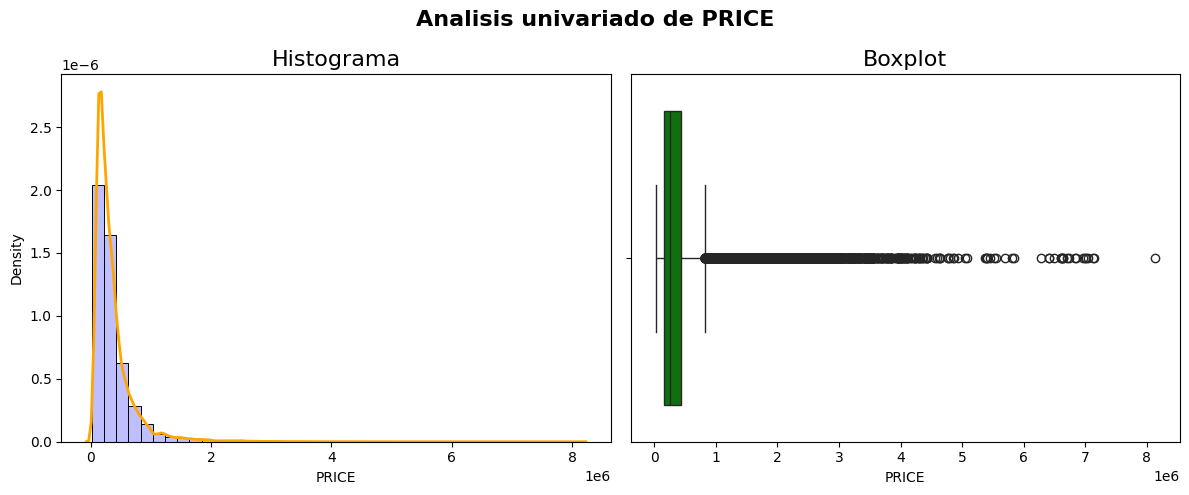


---
### 📝 Conclusiones del análisis univariado numérico para la columna `PRICE`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `4.1835`
- Curtosis: `33.4136`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `PRICE`.  



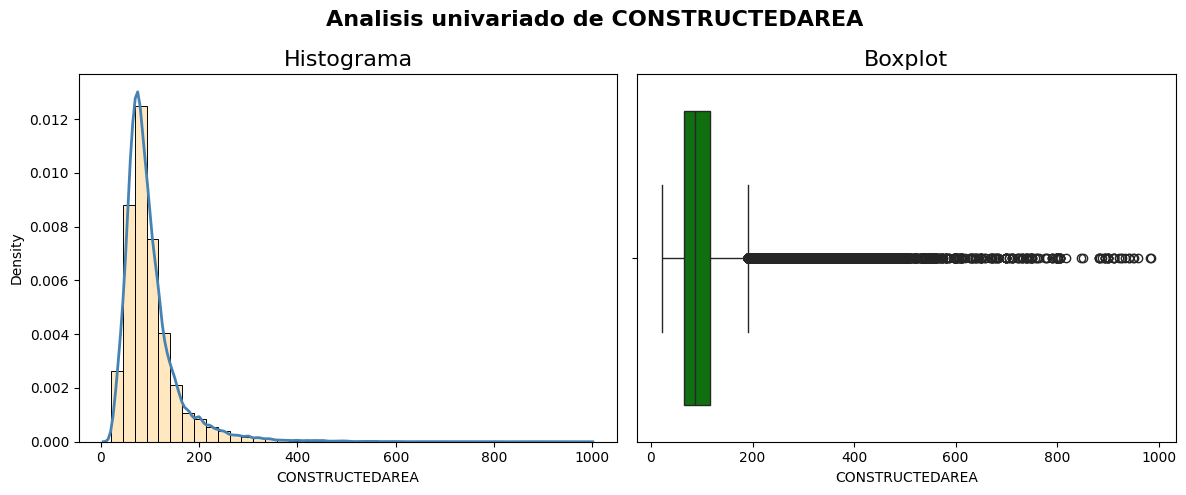


---
### 📝 Conclusiones del análisis univariado numérico para la columna `CONSTRUCTEDAREA`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `3.3752`
- Curtosis: `21.5852`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `CONSTRUCTEDAREA`.  



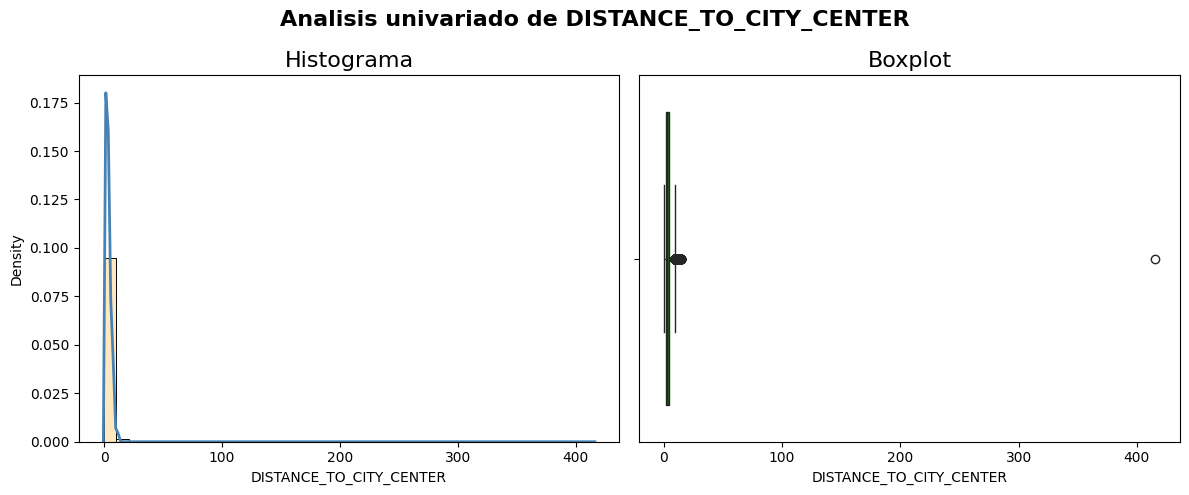


---
### 📝 Conclusiones del análisis univariado numérico para la columna `DISTANCE_TO_CITY_CENTER`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `23.5154`
- Curtosis: `3678.2858`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `DISTANCE_TO_CITY_CENTER`.  



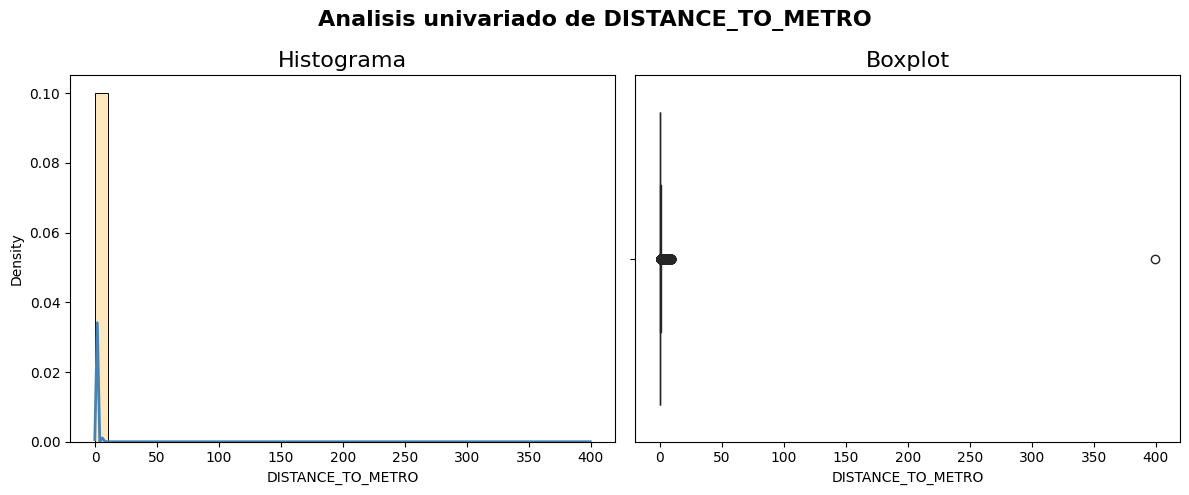


---
### 📝 Conclusiones del análisis univariado numérico para la columna `DISTANCE_TO_METRO`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `297.0932`
- Curtosis: `113614.2917`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `DISTANCE_TO_METRO`.  



In [98]:
# Analizamos la distribución de cada columna numérica con un histograma y un boxplot para ver la forma de la distribución 
# y los posibles outliers.

# Analisis univariado numerico para la columna PRICE.

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de PRICE", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(df_idealista_limpio["PRICE"], 
             bins = 40, 
             alpha = 0.25, 
             color= "blue", 
             edgecolor = "black",
             stat="density") # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["PRICE"],
             color = "orange",
             linewidth = 2)

plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["PRICE"], color= "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ PRICE ]")
# print("="*120)
# print("-> Distribucion log-normal")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["PRICE"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["PRICE"].kurtosis()}")
# print("="*120)
# print("-> Skewness extremadamente alto : cola derecha muy larga")
# print("-> Kurtosis extremadamente alto : existe outliers que son extremos no indica la cantidad de outliers")
# print("-> Boxplot con muchísimos outliers,  muchos valores extremos en la columna PRICE.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `PRICE`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["PRICE"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["PRICE"].kurtosis():.4f}`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `PRICE`.  

"""

display(Markdown(md))

# Analisis univariado numerico para la columna CONSTRUCTEDAREA.
plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de CONSTRUCTEDAREA", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(df_idealista_limpio["CONSTRUCTEDAREA"], 
            #kde=True,
            # kde_kws={"color": "blue", "linewidth": 2},
             bins = 40, 
             alpha = 0.25, 
             color= "orange", 
             edgecolor = "black",
             stat ="density",
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["CONSTRUCTEDAREA"],
             color = "steelblue",
             linewidth = 2)
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["CONSTRUCTEDAREA"], color= "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ CONSTRUCTEDAREA ]")
# print("="*120)
# print("-> Distribucion log-normal")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["CONSTRUCTEDAREA"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["CONSTRUCTEDAREA"].kurtosis()}")
# print("="*120)
# print("-> Skewness extremadamente alto : cola derecha muy larga")
# print("-> Kurtosis extremadamente alto : existe outliers que son extremos no indica la cantidad de outliers")
# print("-> Boxplot con muchísimos outliers,  muchos valores extremos en la columna CONSTRUCTEDAREA.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `CONSTRUCTEDAREA`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["CONSTRUCTEDAREA"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["CONSTRUCTEDAREA"].kurtosis():.4f}`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `CONSTRUCTEDAREA`.  

"""

display(Markdown(md))

# Analisis univariado numerico para la columna DISTANCE_TO_CITY_CENTER.
plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de DISTANCE_TO_CITY_CENTER", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(df_idealista_limpio["DISTANCE_TO_CITY_CENTER"], 
            # kde=True,
            # kde_kws={"color": "blue", "linewidth": 2},
             bins = 40, 
             alpha = 0.25, 
             color= "orange", 
             edgecolor = "black",
             stat ="density",
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["DISTANCE_TO_CITY_CENTER"],
             color = "steelblue",
             linewidth = 2)
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["DISTANCE_TO_CITY_CENTER"], color= "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ DISTANCE_TO_CITY_CENTER ]")
# print("="*120)
# print("-> Distribucion log-normal")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].kurtosis()}")
# print("="*120)
# print("-> Skewness extremadamente alto : cola derecha muy larga")
# print("-> Kurtosis extremadamente alto : existe outliers que son extremos no indica la cantidad de outliers")
# print("-> Boxplot con muchísimos outliers, con algun outlier extremo en la columna DISTANCE_TO_CITY_CENTER.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `DISTANCE_TO_CITY_CENTER`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].kurtosis():.4f}`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `DISTANCE_TO_CITY_CENTER`.  

"""

display(Markdown(md))

# Analisis univariado numerico para la columna DISTANCE_TO_METRO.
plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de DISTANCE_TO_METRO", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(df_idealista_limpio["DISTANCE_TO_METRO"], 
            # kde=True,
            # kde_kws={"color": "blue", "linewidth": 2},
             bins = 40, 
             alpha = 0.25, 
             color= "orange", 
             edgecolor = "black",
             stat ="density",
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["DISTANCE_TO_METRO"],
             color = "steelblue",
             linewidth = 2)
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["DISTANCE_TO_METRO"], color= "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ DISTANCE_TO_METRO ]")
# print("="*120)
# print("-> Distribucion log-normal")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["DISTANCE_TO_METRO"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["DISTANCE_TO_METRO"].kurtosis()}")
# print("="*120)
# print("-> Skewness extremadamente alto : cola derecha muy larga")
# print("-> Kurtosis extremadamente alto : existe outliers que son extremos no indica la cantidad de outliers")
# print("-> Boxplot con muchísimos outliers, con algun outlier extremo en la columna DISTANCE_TO_METRO.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `DISTANCE_TO_METRO`
---
**Distribución:** log-normal  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["DISTANCE_TO_METRO"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["DISTANCE_TO_METRO"].kurtosis():.4f}`  

**Interpretación**

- Skewness extremadamente alto: cola derecha muy larga.  
- Kurtosis extremadamente alto: existen outliers que son extremos (no indica la cantidad).  
- Boxplot con muchísimos outliers: muchos valores extremos en la columna `DISTANCE_TO_METRO`.  

"""

display(Markdown(md))


## Feature Engineering
---
*   **Feature Engineering:** Crear nuevas variables derivadas que aporten valor al estudio o transformar las existentes para facilitar el posterior análisis estadístico y modelado.

In [101]:
# Incorporamos campos nuevos en el dataset para hacer graficos y Feature Engineering.

df_idealista_limpio["PRECIO_POR_METRO"]            = df_idealista_limpio["PRICE"] / df_idealista_limpio["CONSTRUCTEDAREA"]
df_idealista_limpio["LOG_PRICE"]                   = df_idealista_limpio["PRICE"].apply(np.log1p)
df_idealista_limpio["LOG_CONSTRUCTEDAREA"]         = df_idealista_limpio["CONSTRUCTEDAREA"].apply(np.log1p)
df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"] = df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].apply(np.log1p)
df_idealista_limpio["LOG_DISTANCE_TO_METRO"]       = df_idealista_limpio["DISTANCE_TO_METRO"].apply(np.log1p)
df_idealista_limpio["LOG_PRECIO_POR_METRO"]        = df_idealista_limpio["LOG_PRICE"] / df_idealista_limpio["LOG_CONSTRUCTEDAREA"]

#======================================================================================================================================
# --> Importante concepto de log1p o log .
#======================================================================================================================================
# porque utilizamos np.log1p en lugar de np.log? Porque np.log1p(x) calcula el logaritmo natural de (1 + x), 
# lo que es útil para evitar problemas con valores cero o negativos, ya que log(0) es indefinido y log de números negativos no es real.
#  Al usar np.log1p, podemos manejar estos casos sin generar errores, lo que es especialmente importante en análisis de datos donde 
# pueden existir valores cero o negativos en las columnas numéricas.
#======================================================================================================================================

# Mostramos las nuevas columnas para ver que se han creado correctamente.
df_idealista_limpio[["LOG_PRICE","LOG_CONSTRUCTEDAREA","LOG_DISTANCE_TO_CITY_CENTER","LOG_DISTANCE_TO_METRO","LOG_PRECIO_POR_METRO"]].head(10)

,LOG_PRICE,LOG_CONSTRUCTEDAREA,LOG_DISTANCE_TO_CITY_CENTER,LOG_DISTANCE_TO_METRO,LOG_PRECIO_POR_METRO
0,11.599112,4.158883,1.642217,0.272717,2.788997
1,11.951187,4.189655,1.700601,0.103968,2.852547
2,11.970357,4.369448,1.666754,0.196838,2.739558
3,11.744045,4.330733,1.768481,0.304346,2.711791
4,12.122696,4.615121,1.755521,0.333042,2.626735
5,11.719948,4.394449,1.645099,0.278424,2.666989
6,11.635152,4.262680,1.645289,0.259617,2.729539
7,11.385103,4.189655,1.726233,0.234550,2.717432
8,12.301387,4.394449,1.705085,0.056470,2.799301
9,12.669810,4.682131,1.819878,0.487207,2.705992


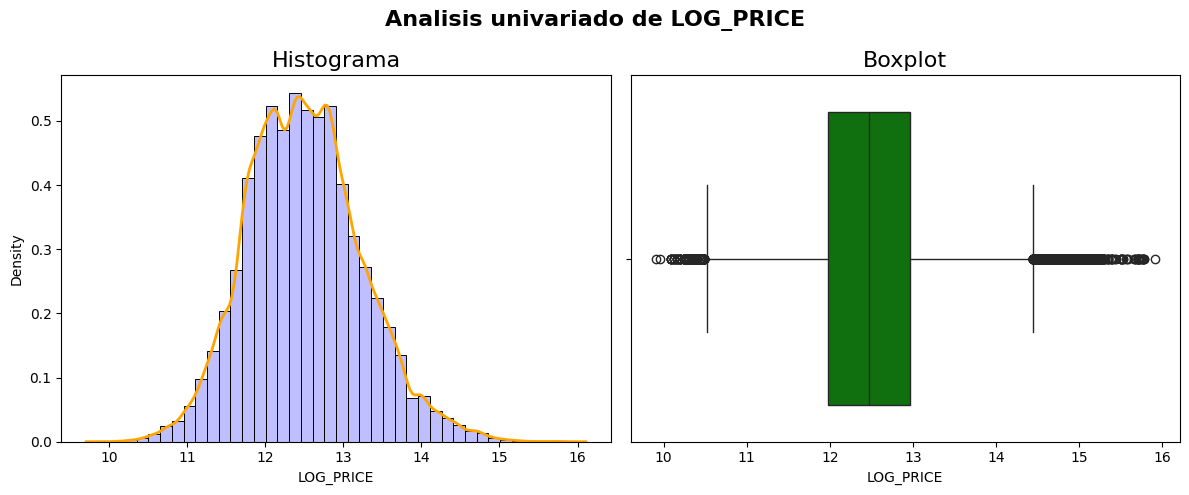


---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_PRICE`
---
**Distribución:** normal simétrica  

**Asimetría y curtosis**

- Asimetría: `0.2969`
- Curtosis: `0.1839`  

**Interpretación**

- Skewness < 0.5 → casi simétrica.  
- Kurtosis cercano a 0 → parecido a normal.  
- Boxplot con outliers por los dos lados, pero con los mismos outliers que en la columna `PRICE`.  



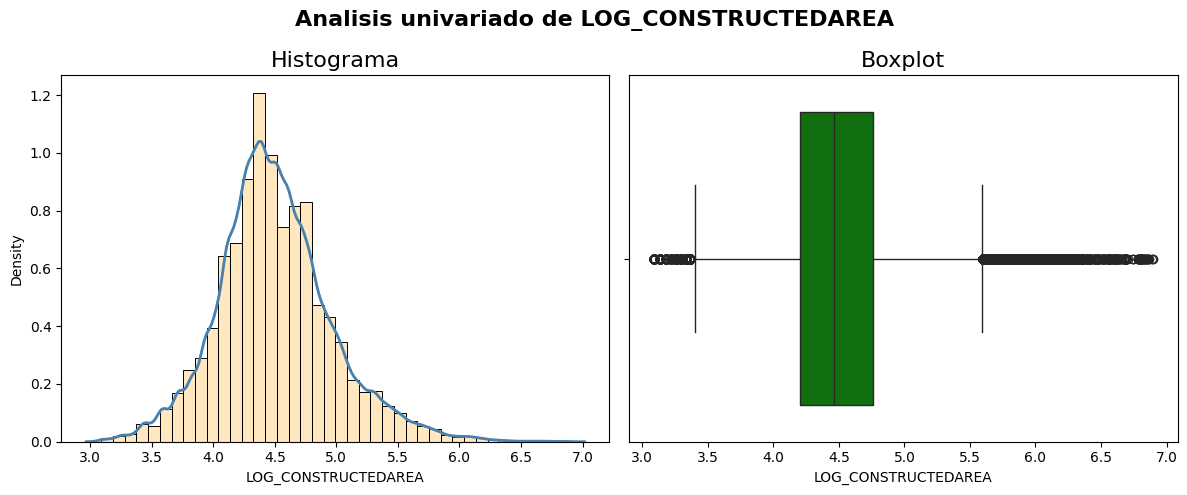


---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_CONSTRUCTEDAREA`
---
**Distribución:** normal simétrica  

**Asimetría y curtosis**

- Asimetría: `0.4898`
- Curtosis: `1.0309`  

**Interpretación**

- Skewness < 0.5 → casi simétrica.  
- Kurtosis cercano a 0 → parecido a normal.  
- Boxplot con outliers por los dos lados, pero con los mismos outliers que en la columna `LOG_CONSTRUCTEDAREA`.  



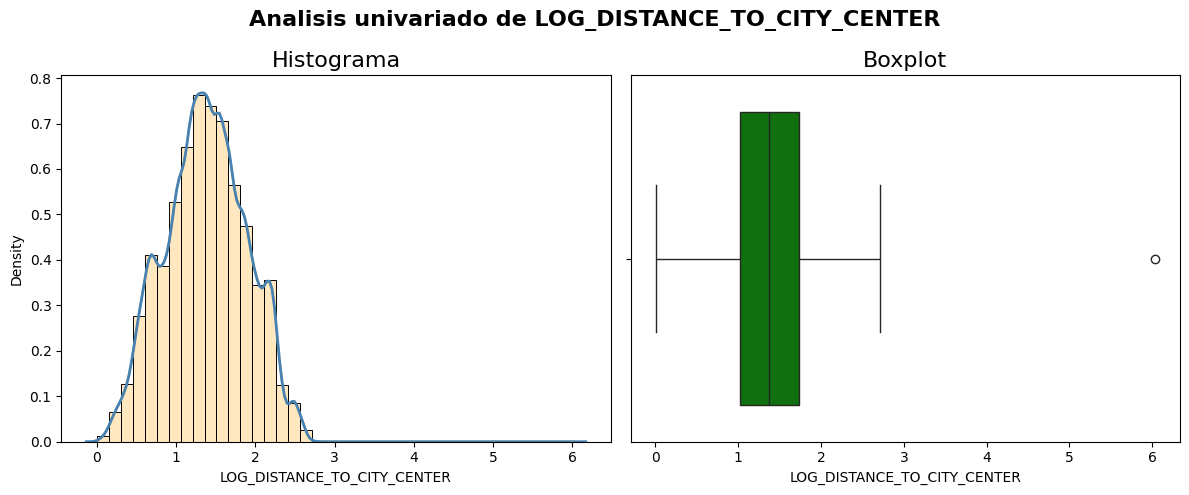


---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_DISTANCE_TO_CITY_CENTER`
---
**Distribución:** normal simétrica  

**Asimetría y curtosis**

- Asimetría: `-0.0069`
- Curtosis: `-0.5213`  

**Interpretación**

- Skewness < 0.5 → casi simétrica.  
- Kurtosis cercano a 0 → parecido a normal.  
- Boxplot con algun outlier lejano en la columna `LOG_DISTANCE_TO_CITY_CENTER`.  



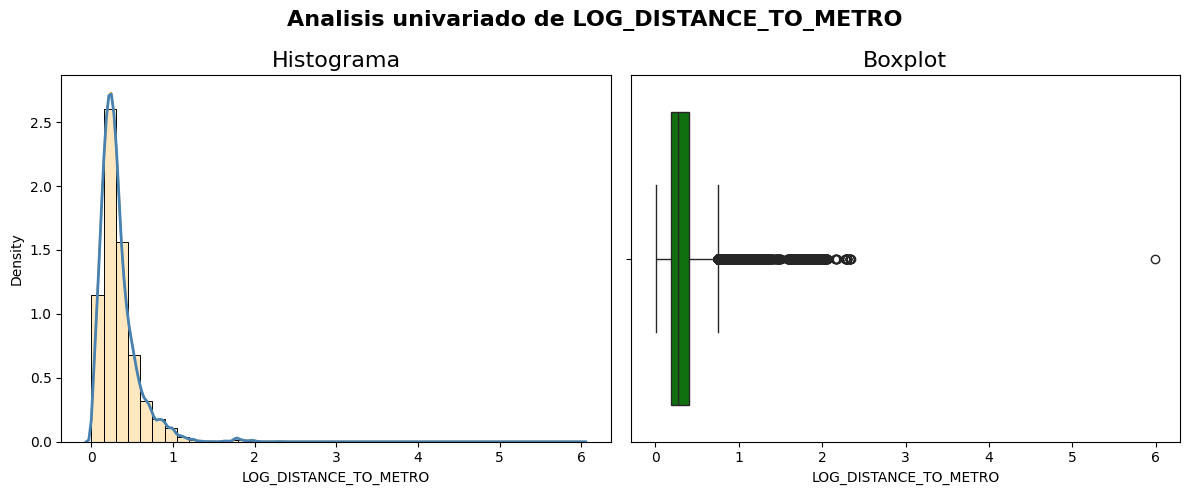


---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_DISTANCE_TO_METRO`
---
**Distribución:** asimétrica a la derecha  

**Asimetría y curtosis**

- Asimetría: `2.4062`
- Curtosis: `11.4227`  

**Interpretación**

- Skewness > 0.5 → asimétrica a la derecha  
- Kurtosis > 0 → colas más pesadas que una distribución normal  
- Boxplot con outliers y alguno lejano en la columna `LOG_DISTANCE_TO_METRO`.  



In [107]:
# Analisis univariado numerico para la columna LOG_PRICE.

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de LOG_PRICE", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["LOG_PRICE"], 
             bins = 40, 
             alpha = 0.25, 
             color= "blue", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["LOG_PRICE"],
             color = "orange",
             linewidth = 2
             )

plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["LOG_PRICE"], color= "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ LOG_PRICE ]")
# print("="*120)
# print("-> Distribucion normal simetrica")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["LOG_PRICE"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["LOG_PRICE"].kurtosis()}")
# print("="*120)
# print("-> Skewness < 0.5 → casi simetrica")
# print("-> Kurtosis cercano 0 → parecido a normal")
# print("-> Boxplot con outliers por los dos lados pero con los mismo outliers en la columna LOG_PRICE.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_PRICE`
---
**Distribución:** normal simétrica  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["LOG_PRICE"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["LOG_PRICE"].kurtosis():.4f}`  

**Interpretación**

- Skewness < 0.5 → casi simétrica.  
- Kurtosis cercano a 0 → parecido a normal.  
- Boxplot con outliers por los dos lados, pero con los mismos outliers que en la columna `PRICE`.  

"""

display(Markdown(md))

# Analisis univariado numerico para la columna LOG_CONSTRUCTEDAREA.
plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de LOG_CONSTRUCTEDAREA", fontsize = 16, fontweight = "bold") # Título general

plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["LOG_CONSTRUCTEDAREA"], 
             kde = True,
             bins = 40, 
             alpha = 0.25, 
             color = "orange", 
             edgecolor = "black",
             stat = "density",
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["LOG_CONSTRUCTEDAREA"],
             color = "steelblue",
             linewidth = 2
            )
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x = df_idealista_limpio["LOG_CONSTRUCTEDAREA"], color = "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ LOG_CONSTRUCTEDAREA ]")
# print("="*120)
# print("-> Distribucion normal simetrica")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["LOG_CONSTRUCTEDAREA"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["LOG_CONSTRUCTEDAREA"].kurtosis()}")
# print("="*120)
# print("-> Skewness < 0.5 → casi simetrica")
# print("-> Kurtosis cercano 0 → parecido a normal")
# print("-> Boxplot con outliers por los dos lados pero con los mismo outliers en la columna LOG_CONSTRUCTEDAREA.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_CONSTRUCTEDAREA`
---
**Distribución:** normal simétrica  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["LOG_CONSTRUCTEDAREA"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["LOG_CONSTRUCTEDAREA"].kurtosis():.4f}`  

**Interpretación**

- Skewness < 0.5 → casi simétrica.  
- Kurtosis cercano a 0 → parecido a normal.  
- Boxplot con outliers por los dos lados, pero con los mismos outliers que en la columna `LOG_CONSTRUCTEDAREA`.  

"""

display(Markdown(md))

# Analisis univariado numerico para la columna LOG_DISTANCE_TO_CITY_CENTER.
plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de LOG_DISTANCE_TO_CITY_CENTER", fontsize = 16, fontweight = "bold") # Título general

plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"], 
             kde = True,
             bins = 40, 
             alpha = 0.25, 
             color = "orange", 
             edgecolor = "black",
             stat = "density",
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"],
             color = "steelblue",
             linewidth = 2
            )
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x = df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"], color = "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ LOG_DISTANCE_TO_CITY_CENTER ]")
# print("="*120)
# print("-> Distribucion normal simetrica")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"].kurtosis()}")
# print("="*120)
# print("-> Skewness < 0.5 → casi simetrica")
# print("-> Kurtosis cercano 0 → parecido a normal")
# print("-> Boxplot con algun outlier lejano en la columna LOG_DISTANCE_TO_CITY_CENTER.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_DISTANCE_TO_CITY_CENTER`
---
**Distribución:** normal simétrica  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"].kurtosis():.4f}`  

**Interpretación**

- Skewness < 0.5 → casi simétrica.  
- Kurtosis cercano a 0 → parecido a normal.  
- Boxplot con algun outlier lejano en la columna `LOG_DISTANCE_TO_CITY_CENTER`.  

"""

display(Markdown(md))

# Analisis univariado numerico para la columna LOG_DISTANCE_TO_METRO.
plt.figure(figsize = (12, 5))
plt.suptitle("Analisis univariado de LOG_DISTANCE_TO_METRO", fontsize = 16, fontweight = "bold") # Título general

plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["LOG_DISTANCE_TO_METRO"], 
             kde = True,
             bins = 40, 
             alpha = 0.25, 
             color = "orange", 
             edgecolor = "black",
             stat = "density",
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["LOG_DISTANCE_TO_METRO"],
             color = "steelblue",
             linewidth = 2
            )
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x = df_idealista_limpio["LOG_DISTANCE_TO_METRO"], color = "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

# print("="*120)
# print("-> Conclusiones del análisis univariado numerico para la columna [ LOG_DISTANCE_TO_METRO ]")
# print("="*120)
# print("-> Distribucion asimetrica a la derecha")
# print("="*120)
# print("-> Asimetria y Curtosis")
# print(f"Asimetria: {df_idealista_limpio["LOG_DISTANCE_TO_METRO"].skew()}")
# print(f"Curtosis: {df_idealista_limpio["LOG_DISTANCE_TO_METRO"].kurtosis()}")
# print("="*120)
# print("-> Skewness > 0.5 → asimetrica a la derecha")
# print("-> Kurtosis > 0 → colas más pesadas que una distribución normal")
# print("-> Boxplot con outliers y alguno lejano en la columna LOG_DISTANCE_TO_METRO.")
# print("="*120)
# print("\n")

md = f"""
---
### 📝 Conclusiones del análisis univariado numérico para la columna `LOG_DISTANCE_TO_METRO`
---
**Distribución:** asimétrica a la derecha  

**Asimetría y curtosis**

- Asimetría: `{df_idealista_limpio["LOG_DISTANCE_TO_METRO"].skew():.4f}`
- Curtosis: `{df_idealista_limpio["LOG_DISTANCE_TO_METRO"].kurtosis():.4f}`  

**Interpretación**

- Skewness > 0.5 → asimétrica a la derecha  
- Kurtosis > 0 → colas más pesadas que una distribución normal  
- Boxplot con outliers y alguno lejano en la columna `LOG_DISTANCE_TO_METRO`.  

"""

display(Markdown(md))

In [108]:

# Lista columnas numericas cualitativas.
lista_columnas_numericas_cualitativas: list[str] = ["CADASTRALQUALITYID" , "FLOORCLEAN", "ROOMNUMBER", "BATHNUMBER",  "CADCONSTRUCTIONYEAR", "CADMAXBUILDINGFLOOR"]

print("="*160)
print(f"--> Lista columnas numericas cualitativas {lista_columnas_numericas_cualitativas} ")
print("="*160)
print("\n")

# CADASTRALQUALITYID [ Cualitativa ] : 0 sin información, 1-3 acabados de lujo, 4-6 acabados estándar, 7-9 acabados económicos.
condiciones: list = [
                      df_idealista_limpio["CADASTRALQUALITYID"].between(1,3),
                      df_idealista_limpio["CADASTRALQUALITYID"].between(4,6),
                      df_idealista_limpio["CADASTRALQUALITYID"].between(7,9),
                      df_idealista_limpio["CADASTRALQUALITYID"] == 0,
                    ]

opciones: list[str] = [
                       "acabados de lujo  ",
                       "acabados estandar ",
                       "acabados economicos",
                       "sin informacion"
                      ]

df_idealista_limpio["bin_tipo_acabado"] = np.select(
                                                    condiciones,
                                                    opciones,
                                                    df_idealista_limpio["CADASTRALQUALITYID"]
                                                   )

print("="*150)
print("--> Lista valores unicos [ bin_tipo_acabado ]")
print("="*150)
valores = df_idealista_limpio["bin_tipo_acabado"].unique()
print("[",", ".join(map(str, valores)), "]")   # todo en una sola línea
print("="*150)
print("\n")

df_idealista_limpio[["CADASTRALQUALITYID", "bin_tipo_acabado"]].head(10)

# FLOORCLEAN [ Cualitativa ] : plantas de un edificio

df_idealista_limpio["FLOORCLEAN"].value_counts()
df_idealista_limpio["FLOORCLEAN"].isna().sum()

map_floor = {
            np.nan  : "nan",
            -1.0    : "Sótano",
             0.0    : "Bajo",
             1.0    : "1ª",
             2.0    : "2ª",
             3.0    : "3ª",
             4.0    : "4ª",
             5.0    : "5ª",
             6.0    : "6ª",
             7.0    : "7ª",
             8.0    : "8ª",
             9.0    : "9ª",
             10.0   : "10ª",
             11.0   : "11ª"
             }

df_idealista_limpio["bin_floorclean"] = df_idealista_limpio["FLOORCLEAN"].map(map_floor)

df_idealista_limpio[["FLOORCLEAN", "bin_floorclean"]].head(10)

print("="*150)
print("--> Lista valores unicos [ bin_floorclean ]")
print("="*150)
valores = df_idealista_limpio["bin_floorclean"].unique()
print("[",", ".join(map(str, valores)), "]")   # todo en una sola línea
print("="*150)
print("\n")


# ROOMNUMBER [ Cualitativa ] : numero de habitaciones, 0 sin información, 1-2 pocas habitaciones, 3-4 habitaciones estándar, 5 o más muchas habitaciones.

# Agrupamos los valores de ROOMNUMBER en categorias.
df_idealista_limpio["ROOMNUMBER"].value_counts(dropna=False)
#Y la mayoría (96.45%) de los valores se concentran entre 1 y 4 (incluidos NaNs)
entre_1_y_4: int = df_idealista_limpio["ROOMNUMBER"].between(1, 4).sum() + df_idealista_limpio["ROOMNUMBER"].isna().sum()

print("="*150)
print("--> Porcentaje entre 1 y 4 valores unicos [ ROOMNUMBER ]")
print("="*150)
print(f" Total Porcentaje : {entre_1_y_4 / df_idealista_limpio.shape[0] * 100:.2f}%")
print("="*150)
print("\n")

condiciones: list = [
                    df_idealista_limpio['ROOMNUMBER'] == 0,
                    df_idealista_limpio['ROOMNUMBER'] == 1,
                    df_idealista_limpio['ROOMNUMBER'] == 2,
                    df_idealista_limpio['ROOMNUMBER'] == 3,
                    df_idealista_limpio['ROOMNUMBER'] >= 4
     ]

opciones: list[str] = [
                        "sin habitaciones ",
                        "1 habitación",
                        "2 habitaciones",
                        "3 habitaciones",
                        "4+ habitaciones"
                      ]

df_idealista_limpio["bin_habitaciones"] = np.select(
                                                    condiciones,
                                                    opciones,
                                                   df_idealista_limpio["ROOMNUMBER"]
                                                   )


df_idealista_limpio[["ROOMNUMBER", "bin_habitaciones"]].head(10)


print("="*150)
print("--> Lista valores unicos [ bin_habitaciones ]")
print("="*150)
valores = df_idealista_limpio["bin_habitaciones"].unique()
print("[",", ".join(map(str, valores)), "]")   # todo en una sola línea
print("="*150)
print("\n")

# BATHNUMBER [ Cualitativa ] : numero de baños, 0 sin información, 1-2 pocos baños, 3-4 baños estándar, 5 o más muchos baños.

# Agrupamos los valores de BATHNUMBER en categorias.
#Y la mayoría (97.54%) de los valores se concentran entre 1 y 3 (incluidos NaNs)
entre_1_y_3: int = df_idealista_limpio["BATHNUMBER"].between(1, 3).sum() + df_idealista_limpio["BATHNUMBER"].isna().sum()

print("="*150)
print("--> Porcentaje entre 1 y 3 valores unicos [ BATHNUMBER ]")
print("="*150)
print(f" Total Porcentaje : {entre_1_y_3 / df_idealista_limpio.shape[0] * 100:.2f}%")
print("="*150)
print("\n")

condiciones: list = [
                        df_idealista_limpio['BATHNUMBER'] == 0,
                        df_idealista_limpio['BATHNUMBER'] == 1,
                        df_idealista_limpio['BATHNUMBER'] == 2,
                        df_idealista_limpio['BATHNUMBER'] == 3,
                        df_idealista_limpio['BATHNUMBER'] >= 4,
                    ]

opciones: list[str] = [
                        "sin baños ",
                        "1 baño",
                        "2 baños",
                        "3 baños",
                        "4+ baños",
                      ]

df_idealista_limpio["bin_baños"] = np.select(
                                              condiciones,
                                              opciones,
                                              df_idealista_limpio["BATHNUMBER"]
                                            )

df_idealista_limpio[["BATHNUMBER", "bin_baños"]].head(10)


print("="*150)
print("--> Lista valores unicos [ bin_baños ]")
print("="*150)
valores = df_idealista_limpio["bin_baños"].unique()
print("[",", ".join(map(str, valores)), "]")   # todo en una sola línea
print("="*150)
print("\n")

# CADCONSTRUCTIONYEAR  -- > No tiene sentido agruparlo.

# CADMAXBUILDINGFLOOR [ Cualitativa ] : número máximo de pisos del edificio, 0 sin información, 1-2 edificio bajo o casa, 3-5 edificio tradicional, 6-12 edificio medio, 13-20 edificio alto, 21 o más rascacielos.

condiciones: list = [
                      df_idealista_limpio['CADMAXBUILDINGFLOOR'].between(1,2),
                      df_idealista_limpio['CADMAXBUILDINGFLOOR'].between(3,5),
                      df_idealista_limpio['CADMAXBUILDINGFLOOR'].between(6,12),
                      df_idealista_limpio['CADMAXBUILDINGFLOOR'] .between(13,20),
                      df_idealista_limpio['CADMAXBUILDINGFLOOR'] >=21,
                      df_idealista_limpio['CADMAXBUILDINGFLOOR'] == 0,
                    ]

opciones: list[str] = [
                        "edificio bajo o casa ",
                        "edificiotradicional",
                        "edificio medio",
                        "edificio alto",
                        "rascacielos",
                        "sin informacion"
                      ]

df_idealista_limpio["bin_tipo_edificio"] = np.select(
                                                      condiciones,
                                                      opciones,
                                                      df_idealista_limpio["CADMAXBUILDINGFLOOR"]
                                                    )

print("="*150)
print("--> Lista valores unicos [ bin_tipo_edificio ]")
print("="*150)
valores = df_idealista_limpio["bin_tipo_edificio"].unique()
print("[",", ".join(map(str, valores)), "]")   # todo en una sola línea
print("="*150)
print("\n") 


# CADDWELLINGCOUNT [ Cualitativa ]

condiciones: list = [
                      df_idealista_limpio["CADDWELLINGCOUNT"] == 0,
                      df_idealista_limpio["CADDWELLINGCOUNT"] == 1,
                      df_idealista_limpio["CADDWELLINGCOUNT"].between(2,4),
                      df_idealista_limpio["CADDWELLINGCOUNT"].between(5,12),
                      df_idealista_limpio["CADDWELLINGCOUNT"].between(13,70),
                      df_idealista_limpio["CADDWELLINGCOUNT"].between(71,120),
                      df_idealista_limpio["CADDWELLINGCOUNT"] >=121
                    ]

opciones: list[str] = [
                        "sin informacion",
                        "casa",
                        "exclusivo ",
                        "tranquilo",
                        "mediano ",
                        "grande",
                        "colmena" 
                      ]

df_idealista_limpio["bin_categoria_edificio"] = np.select(
                                                            condiciones,
                                                            opciones,
                                                            df_idealista_limpio["CADDWELLINGCOUNT"]
                                                          )

print("="*150)
print("--> Lista valores unicos [ bin_categoria_edificio ]")
print("="*150)
valores = df_idealista_limpio["bin_tipo_edificio"].unique()
print("[",", ".join(map(str, valores)), "]")   # todo en una sola línea
print("="*150)
print("\n") 



--> Lista columnas numericas cualitativas ['CADASTRALQUALITYID', 'FLOORCLEAN', 'ROOMNUMBER', 'BATHNUMBER', 'CADCONSTRUCTIONYEAR', 'CADMAXBUILDINGFLOOR'] 


--> Lista valores unicos [ bin_tipo_acabado ]
[ acabados economicos, acabados estandar , acabados de lujo  , sin informacion, nan ]


--> Lista valores unicos [ bin_floorclean ]
[ 3ª, 4ª, 2ª, 1ª, 5ª, 8ª, nan, 6ª, 7ª, Bajo, 9ª, 10ª, 11ª, Sótano ]


--> Porcentaje entre 1 y 4 valores unicos [ ROOMNUMBER ]
 Total Porcentaje : 92.52%


--> Lista valores unicos [ bin_habitaciones ]
[ 3 habitaciones, 2 habitaciones, 1 habitación, 4+ habitaciones, sin habitaciones  ]


--> Porcentaje entre 1 y 3 valores unicos [ BATHNUMBER ]
 Total Porcentaje : 97.54%


--> Lista valores unicos [ bin_baños ]
[ 1 baño, 2 baños, 3 baños, sin baños , 4+ baños ]


--> Lista valores unicos [ bin_tipo_edificio ]
[ edificiotradicional, edificio medio, edificio alto, edificio bajo o casa , rascacielos, sin informacion ]


--> Lista valores unicos [ bin_categoria_e


---
```text
➡️ Lista columnas numericas cualitativas 
FLOORCLEAN, ROOMNUMBER, BATHNUMBER, CADMAXBUILDINGFLOOR, CADDWELLINGCOUNT  para agrupar la dispersion de los datos y hacer graficos mas claros
```
---


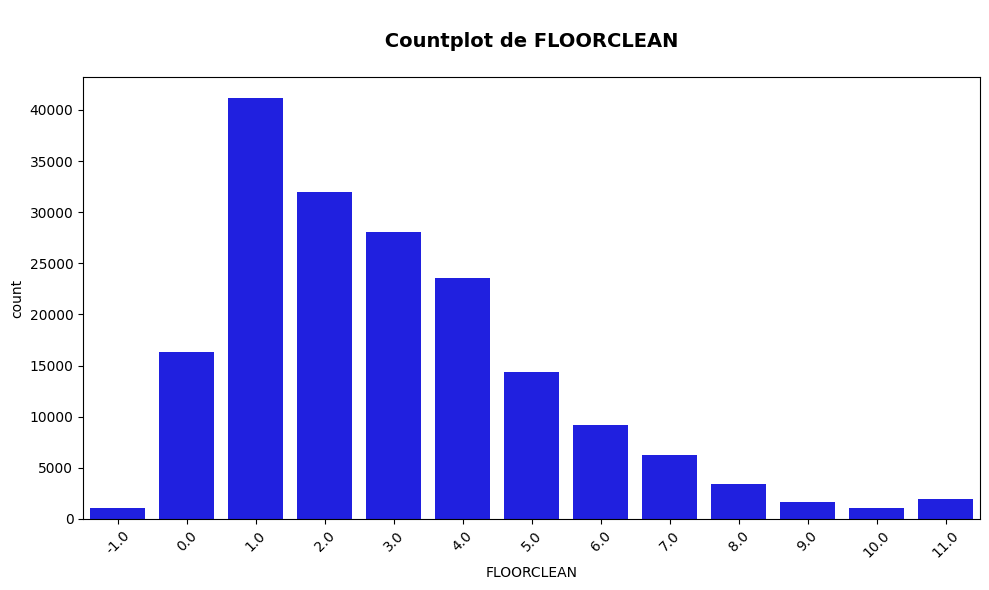

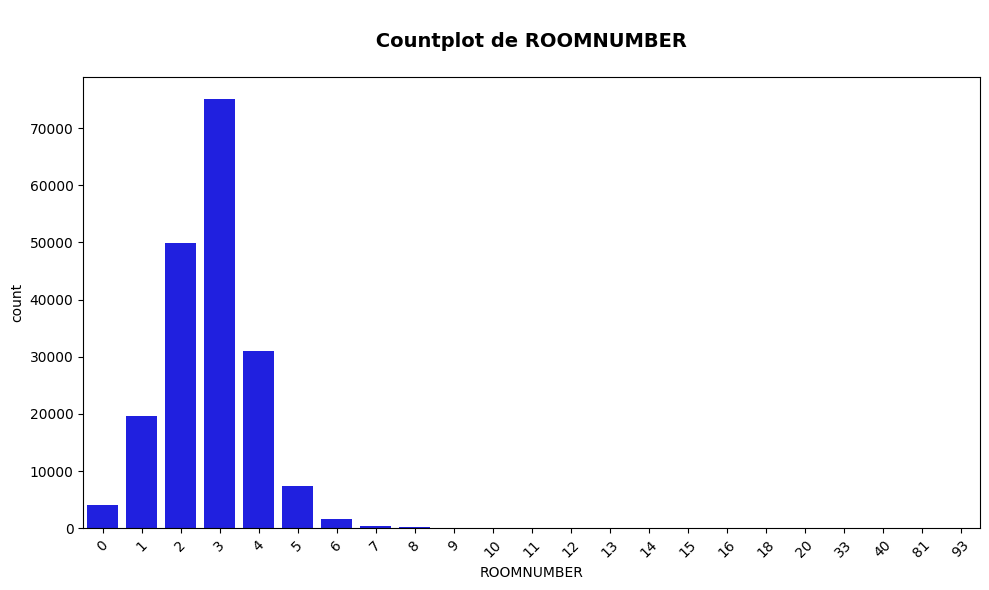

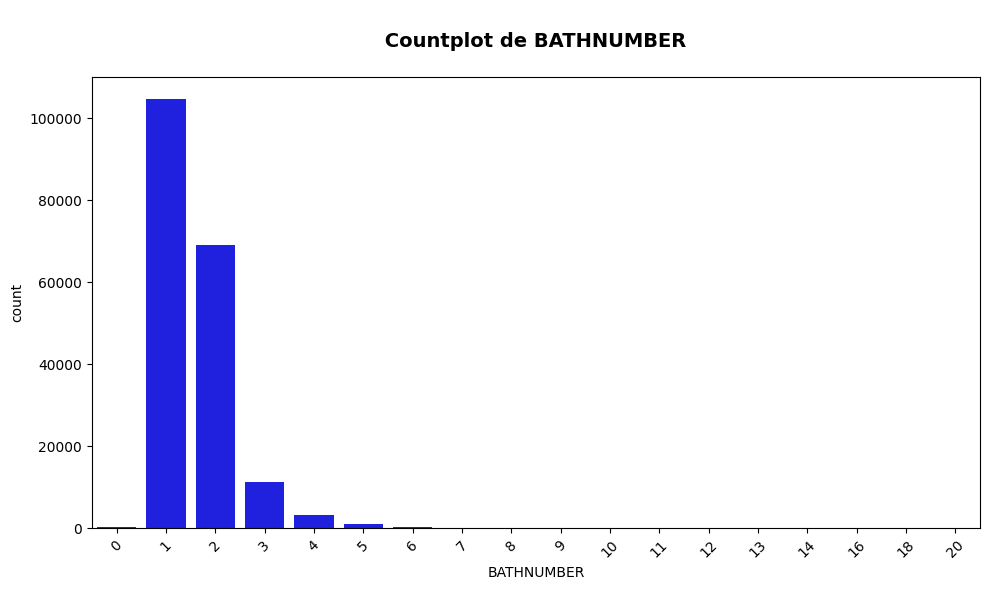

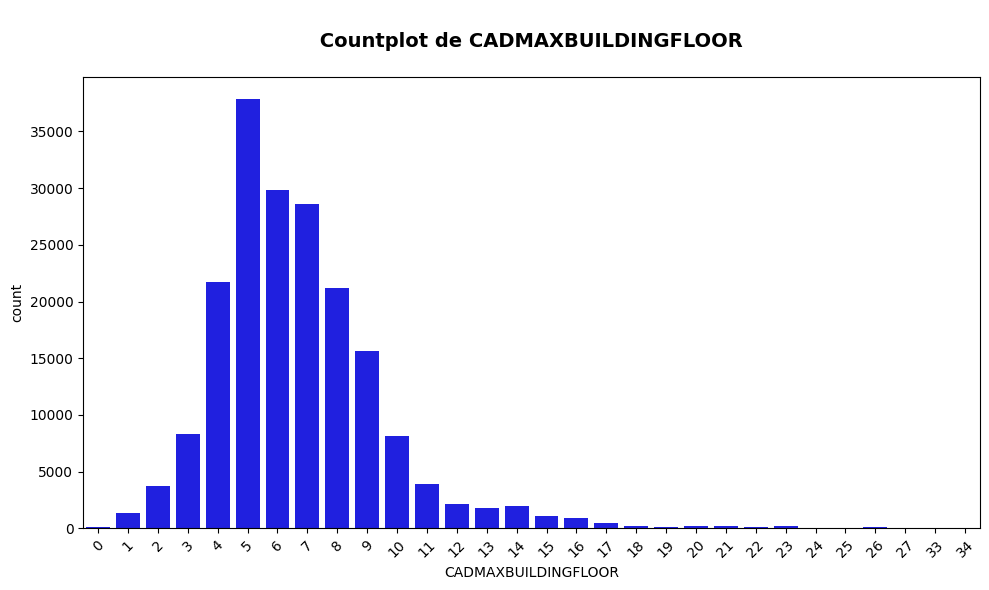

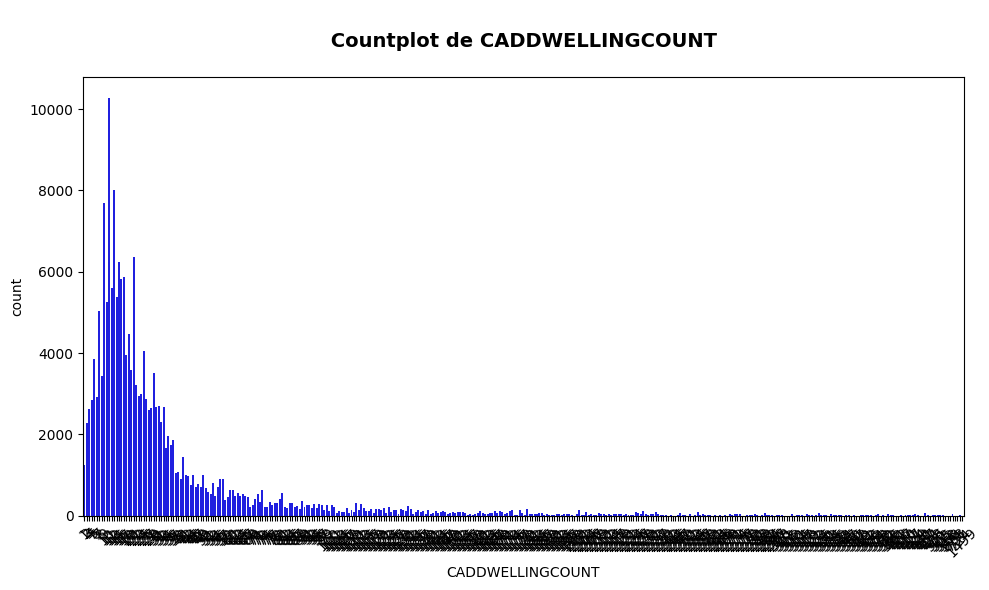

In [129]:
columnas_cualitativas: list[str] = [ "FLOORCLEAN", "ROOMNUMBER", "BATHNUMBER", "CADMAXBUILDINGFLOOR", "CADDWELLINGCOUNT" ]

# print("="*150)
# print(f"--> Lista columnas numericas cualitativas [ {columnas_cualitativas} ]")
# print(" para agrupar la dispersion de los datos y hacer graficos mas claros")
# print("="*150)
# print("\n")

md = f"""
---
```text
➡️ Lista columnas numericas cualitativas 
{", ".join(columnas_cualitativas)}  para agrupar la dispersion de los datos y hacer graficos mas claros
```
---
"""

display(Markdown(md))

# Analizamos la distribución de cada columna numérica cualitativa con un countplot para ver la frecuencia de cada categoría.
for columna in columnas_cualitativas:
    plt.figure(figsize = (10,6))
    sns.countplot(x = df_idealista_limpio[columna], color = "blue")
    plt.title(f"\n Countplot de {columna} \n", fontsize=14, fontweight="bold")
    plt.xticks(rotation = 45) # Rotar las etiquetas del eje x para mejorar la legibilidad si es necesario.
    plt.tight_layout()  ### Esto ajusta el espacio automáticamente
    plt.show()


In [126]:
#  Analisis Univariado Numerico
analisis_columnas_numerico = ["PRICE", "CONSTRUCTEDAREA", "BATHNUMBER", "ROOMNUMBER"]
# print("="*150)
# print(f"--> Analisis Univariado Numerico  [ {analisis_columnas_numerico} ]")
# print("="*150)
# print("\n")

md = f"""
---
```text
➡️ Analisis Univariado Numerico 
{", ".join(analisis_columnas_numerico)} 
```
---
"""

display(Markdown(md))

df_idealista_limpio[analisis_columnas_numerico].describe().T  # count, mean, std, min, cuartiles, max


---
```text
➡️ Analisis Univariado Numerico 
PRICE, CONSTRUCTEDAREA, BATHNUMBER, ROOMNUMBER 
```
---


,count,mean,std,min,25%,50%,75%,max
PRICE,189923.0,361225.938933,351673.662275,20000.0,160000.0,261000.0,428000.0,8133000.0
CONSTRUCTEDAREA,189923.0,100.811476,59.650332,21.0,66.0,86.0,116.0,985.0
BATHNUMBER,189923.0,1.563897,0.769913,0.0,1.0,1.0,2.0,20.0
ROOMNUMBER,189923.0,2.758460,1.197386,0.0,2.0,3.0,3.0,93.0


In [125]:
#  Analisis Univariado categorico en columnas categoricas con pocos valores unicos, para ver la frecuencia de cada categoria. 

analisis_columnas_categoricas = ["CITYNAME", "bin_tipo_acabado", "bin_floorclean"]
# print("="*150)
# print(f"--> Analisis Univariado Categorico {analisis_columnas_categoricas} ")
# print("="*150)
# print("\n")

md = f"""
---
```text
➡️ Analisis Univariado Categorico 
{", ".join(analisis_columnas_categoricas)} 
```
"""
display(Markdown(md))

# for columna in analisis_columnas_categoricas:
#     print("\n")
#     print("="*80)
#     print(f"-> Analisis de columna [ {columna} ]")
#     print("="*80)
#     print(df_idealista_limpio[columna].value_counts(normalize=True).round(3)*100)
#     print("="*80)

for columna in analisis_columnas_categoricas:
    serie = df_idealista_limpio[columna].value_counts(normalize=True).round(3) * 100

    lineas = []
    for categoria, porcentaje in serie.items():
        lineas.append(f"- **{categoria}**: `{porcentaje:.1f}%`")

    md = f"""
---
### Análisis de columna `{columna}`

{"\n".join(lineas)}

"""
    display(Markdown(md))




---
```text
➡️ Analisis Univariado Categorico 
CITYNAME, bin_tipo_acabado, bin_floorclean 
```



---
### Análisis de columna `CITYNAME`

- **madrid**: `49.9%`
- **barcelona**: `32.4%`
- **valencia**: `17.7%`




---
### Análisis de columna `bin_tipo_acabado`

- **acabados estandar **: `67.8%`
- **acabados de lujo  **: `19.9%`
- **acabados economicos**: `12.0%`
- **sin informacion**: `0.3%`
- **nan**: `0.0%`




---
### Análisis de columna `bin_floorclean`

- **1ª**: `21.7%`
- **2ª**: `16.9%`
- **3ª**: `14.8%`
- **4ª**: `12.4%`
- **Bajo**: `8.6%`
- **5ª**: `7.6%`
- **nan**: `5.2%`
- **6ª**: `4.8%`
- **7ª**: `3.3%`
- **8ª**: `1.8%`
- **11ª**: `1.0%`
- **9ª**: `0.9%`
- **Sótano**: `0.6%`
- **10ª**: `0.6%`



In [124]:
# Analisis de correlacion  entre las columnas numericas para ver si hay alguna relacion entre ellas.

lista_correlacion_columnas_num = ["PRICE", "CONSTRUCTEDAREA", "BATHNUMBER", "ROOMNUMBER","DISTANCE_TO_CITY_CENTER","DISTANCE_TO_METRO","HASLIFT","LATITUDE","LONGITUDE","CADCONSTRUCTIONYEAR"]

# print("="*200)
# print(f"--> Analisis de Correlacion  {lista_correlacion_columnas_num} ")
# print("="*200)
# print("\n")

md = f"""
---
```text
➡️ Analisis de Correlacion 
{", ".join(lista_correlacion_columnas_num)} 
```
"""
display(Markdown(md))

df_idealista_limpio[lista_correlacion_columnas_num].describe().T # count, mean, std, min, cuartiles, max


---
```text
➡️ Analisis de Correlacion 
PRICE, CONSTRUCTEDAREA, BATHNUMBER, ROOMNUMBER, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO, HASLIFT, LATITUDE, LONGITUDE, CADCONSTRUCTIONYEAR 
```


,count,mean,std,min,25%,50%,75%,max
PRICE,189923.0,361225.938933,351673.662275,20000.000000,160000.000000,261000.000000,428000.000000,8.133000e+06
CONSTRUCTEDAREA,189923.0,100.811476,59.650332,21.000000,66.000000,86.000000,116.000000,9.850000e+02
BATHNUMBER,189923.0,1.563897,0.769913,0.000000,1.000000,1.000000,2.000000,2.000000e+01
ROOMNUMBER,189923.0,2.758460,1.197386,0.000000,2.000000,3.000000,3.000000,9.300000e+01
DISTANCE_TO_CITY_CENTER,189923.0,3.517798,2.535680,0.003053,1.779076,2.969085,4.690213,4.157526e+02
DISTANCE_TO_METRO,189923.0,0.440224,1.041154,0.000736,0.201331,0.317727,0.503891,3.994774e+02
LATITUDE,189923.0,40.569587,0.669267,36.756391,40.385510,40.433097,41.380609,4.146777e+01
LONGITUDE,189923.0,-1.205663,2.622044,-3.833611,-3.694041,-0.413439,2.146771,2.221874e+00
CADCONSTRUCTIONYEAR,189923.0,1962.185991,32.061934,1588.000000,1951.000000,1966.000000,1979.000000,2.018000e+03


In [130]:
# Analisis de categorias con catagoricas [ tipo_acabado, bin_floorclean ] para ver si hay alguna relacion entre ellas con una tabla de contingencia.:

pd.crosstab(df_idealista_limpio["bin_tipo_acabado"], df_idealista_limpio["bin_floorclean"], normalize="index")

bin_floorclean,10ª,11ª,1ª,2ª,3ª,4ª,5ª,6ª,7ª,8ª,9ª,Bajo,Sótano,nan
bin_tipo_acabado,,,,,,,,,,,,,,
acabados de lujo,0.009441,0.017375,0.206014,0.149578,0.136990,0.121942,0.092772,0.065295,0.043451,0.026578,0.013011,0.054532,0.005210,0.057811
acabados economicos,0.001669,0.006807,0.212849,0.186501,0.161734,0.134376,0.059283,0.019893,0.015326,0.008036,0.003469,0.124890,0.003381,0.061786
acabados estandar,0.005092,0.008670,0.220643,0.170789,0.148839,0.122760,0.073550,0.047960,0.032685,0.017580,0.008453,0.088344,0.006497,0.048138
nan,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
sin informacion,0.006000,0.062000,0.142000,0.198000,0.118000,0.094000,0.082000,0.098000,0.022000,0.016000,0.010000,0.080000,0.004000,0.068000


In [131]:
# Analisis de numericos con catagoricas [ PRICE, bin_tipo_acabado ] para ver si hay alguna relacion entre ellas con una tabla de contingencia.:

df_idealista_limpio.groupby("bin_tipo_acabado")["PRICE"].agg(["count", "mean", "median", "std"])

,count,mean,median,std
bin_tipo_acabado,,,,
acabados de lujo,37813,6.343858e+05,488000.0,4.902530e+05
acabados economicos,22772,1.706687e+05,132000.0,1.543379e+05
acabados estandar,128837,3.116009e+05,244000.0,2.601003e+05
nan,1,2.150000e+05,215000.0,NaN
sin informacion,500,1.169352e+06,725500.0,1.304993e+06


### Gestión de Outliers
---
*   **Gestión de Outliers:** Identificar valores atípicos mediante métodos estadísticos o visuales y justificar razonadamente su tratamiento.


---
### 🚧 Gestión de outliers para la columna `PRICE` con el método IQR
---
- Valor primer cuartil (Q1): `160000.0000`  
- Valor tercer cuartil (Q3): `428000.0000`  
- Rango intercuartil (IQR): `268000.0000`  
- Límite inferior: `-242000.0000`  
- Límite superior: `830000.0000`  




---
###  Graficas para la columna [`PRICE`] con y sin outliers
---


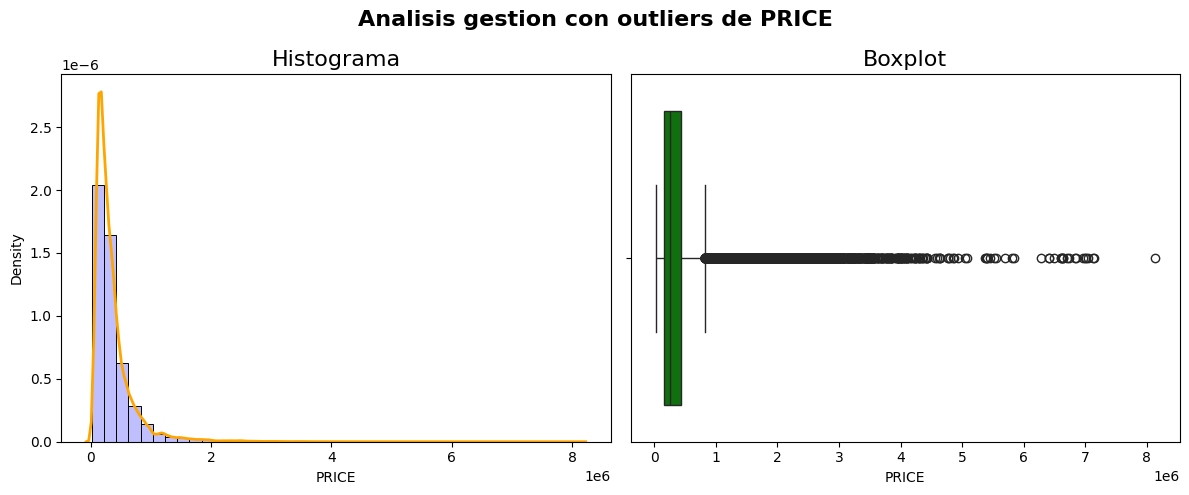

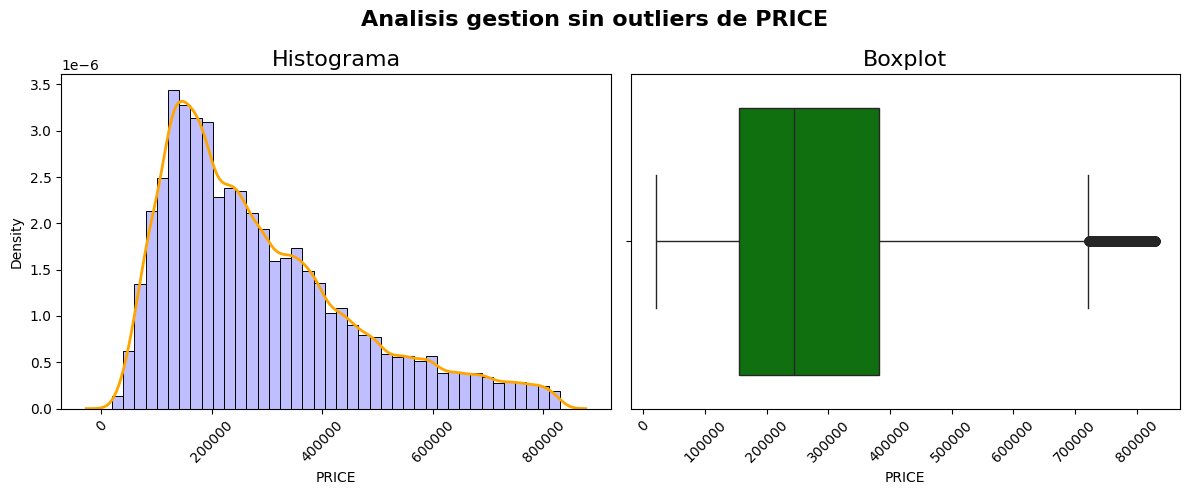


---
### 🚧 Gestión de outliers para la columna `CONSTRUCTEDAREA` con el método IQR
---
- Valor primer cuartil (Q1): `66.0000`  
- Valor tercer cuartil (Q3): `116.0000`  
- Rango intercuartil (IQR): `50.0000`  
- Límite inferior: `-9.0000`  
- Límite superior: `191.0000`  




---
###  Graficas para la columna [ `CONSTRUCTEDAREA` ] con y sin outliers

---


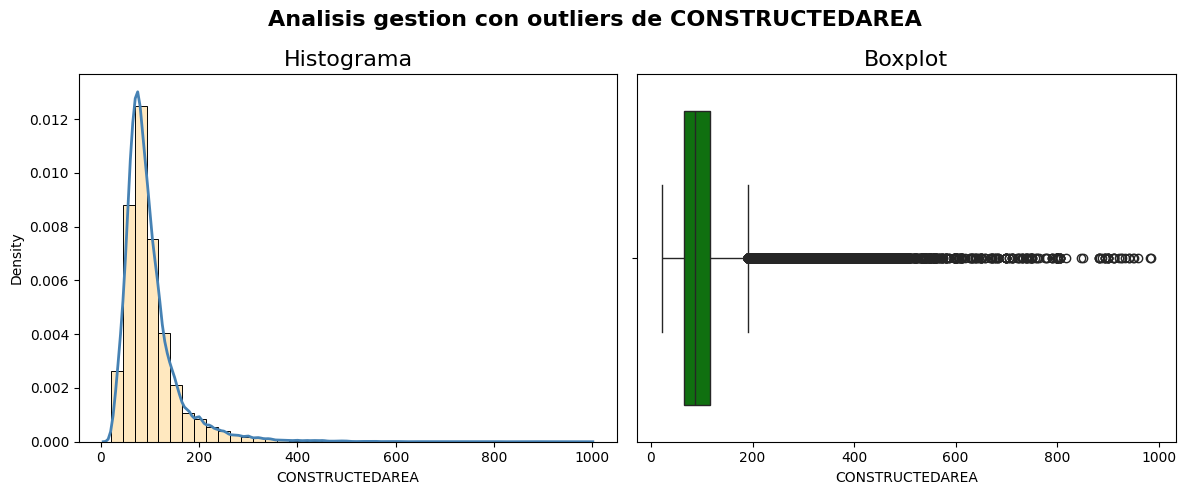

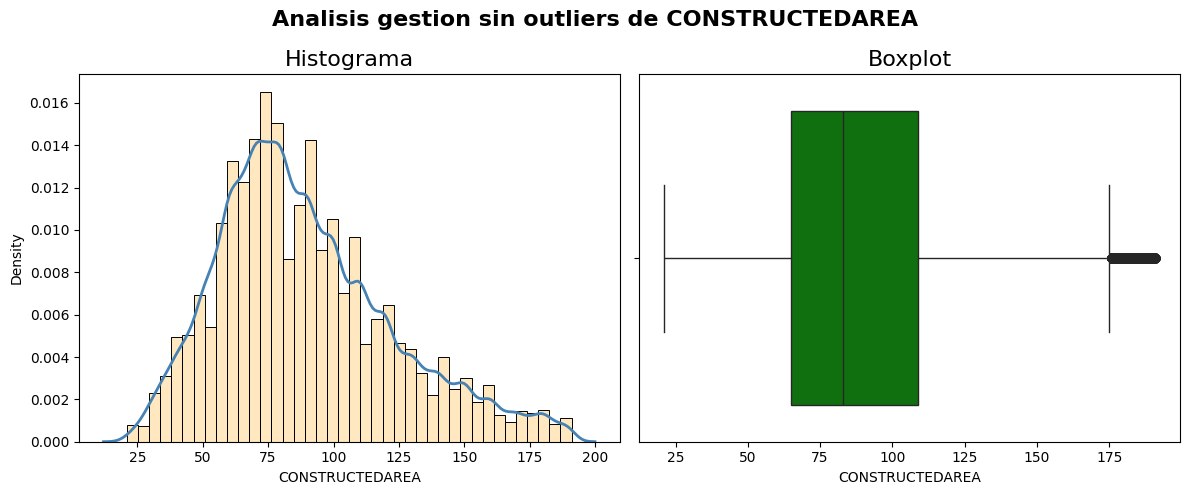


---
### 🚧 Gestión de outliers para la columna `DISTANCE_TO_CITY_CENTER` con el método IQR
---
- Valor primer cuartil (Q1): `1.7791`  
- Valor tercer cuartil (Q3): `4.6902`  
- Rango intercuartil (IQR): `2.9111`  
- Límite inferior: `-2.5876`  
- Límite superior: `9.0569`  




---
###  Graficas para la columna [ `DISTANCE_TO_CITY_CENTER` ] con y sin outliers

---


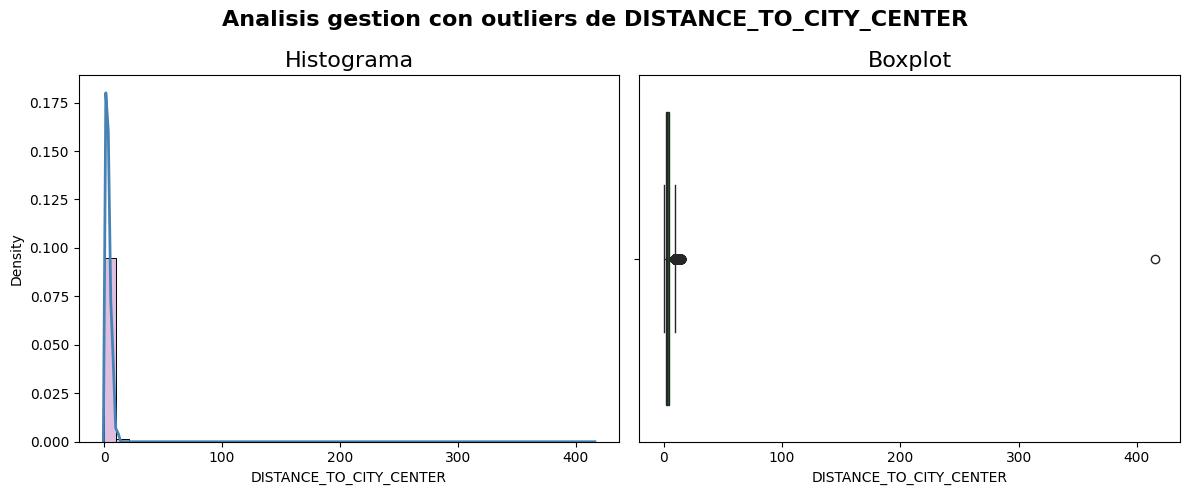

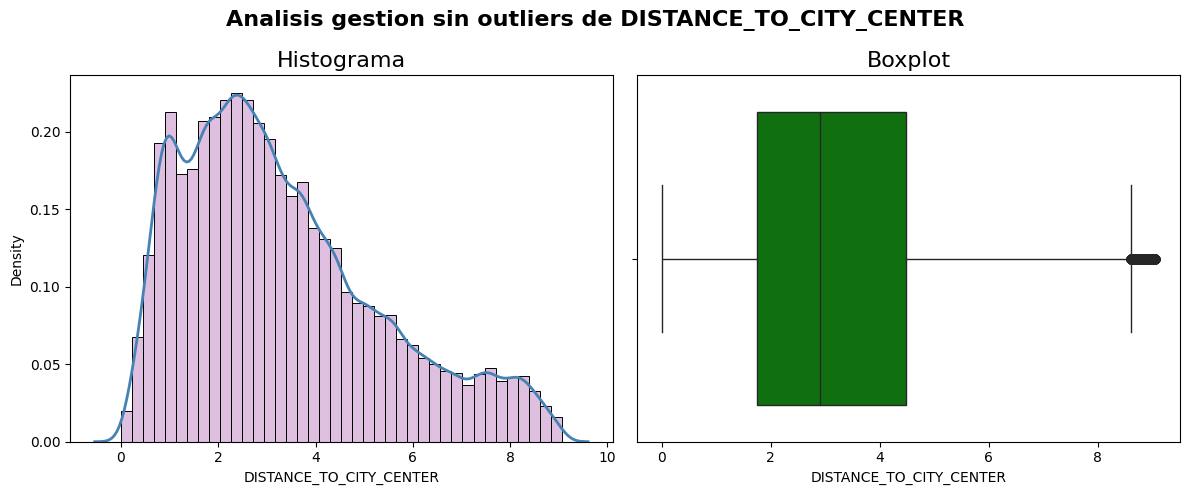


---
### 🚧 Gestión de outliers para la columna `DISTANCE_TO_METRO` con el método IQR
---
- Valor primer cuartil (Q1): `0.2013`  
- Valor tercer cuartil (Q3): `0.5039`  
- Rango intercuartil (IQR): `0.3026`  
- Límite inferior: `-0.2525`  
- Límite superior: `0.9577`  




---
###  Graficas para la columna [` DISTANCE_TO_METRO `] con y sin outliers

---


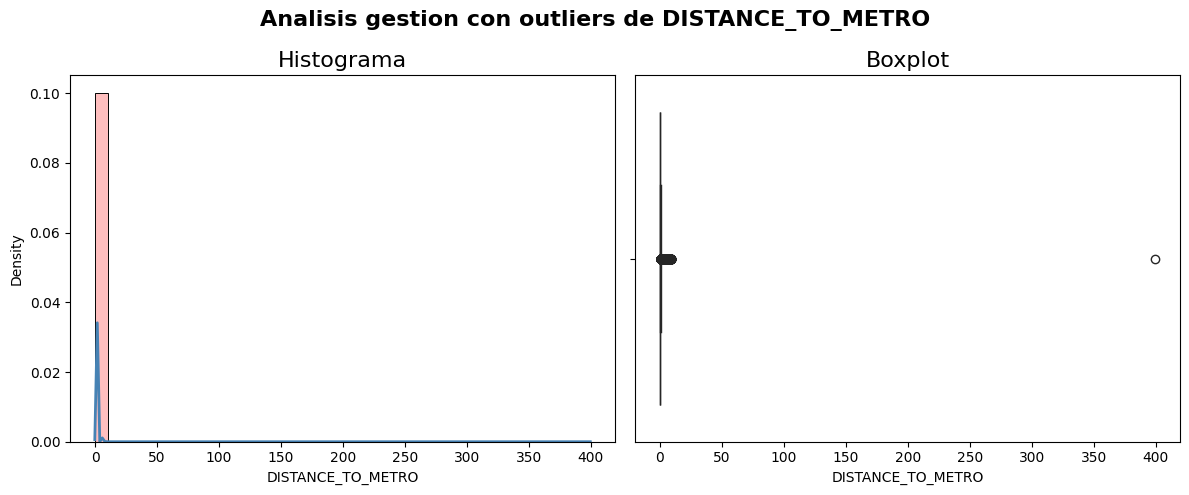

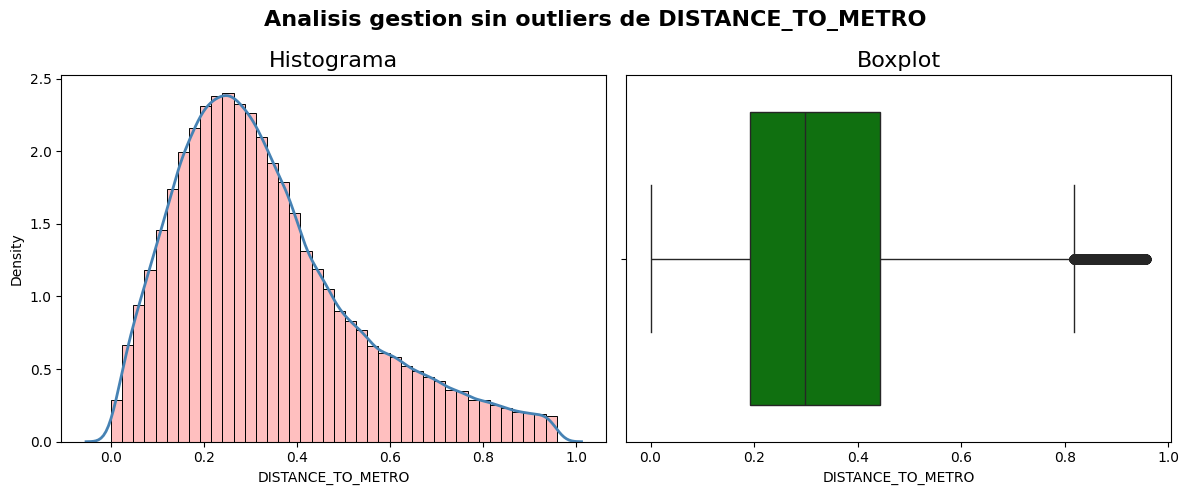

In [136]:
# Analisis gestion de outliers

# En las graficas de boxplot ya habiamos visto que las columnas [ PRICE, CONSTRUCTEDAREA ] tenian muchos outliers.


# Analisis de IQR para la columna [ PRICE ] , para ver cuantos outliers tenemos y que porcentaje de datos eliminamos si eliminamos los outliers.


# Para getionar outliers utilizamos el IQR, para despues calcular ver lo que afecta a la grafica sin outliers de la columna PRICE.
Q1 = df_idealista_limpio["PRICE"].quantile(0.25)
Q3 = df_idealista_limpio["PRICE"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR


# print("="*150)
# print("--> Gestion de outliers para la columna [ PRICE ] con el metodo IQR")
# print("="*150)
# print(f" Valor primer cuartil (Q1) [ {Q1} ]")
# print(f" Valor tercer cuartil (Q3) [ {Q3} ]")
# print(f" Rango intercuartil  (IQR) [ {IQR} ]")
# print(f" Limite inferior           [ {limite_inferior} ]")
# print(f" Limite superior           [ {limite_superior} ]")
# print("="*150)
# print("\n")

md = f"""
---
### 🚧 Gestión de outliers para la columna `PRICE` con el método IQR
---
- Valor primer cuartil (Q1): `{Q1:.4f}`  
- Valor tercer cuartil (Q3): `{Q3:.4f}`  
- Rango intercuartil (IQR): `{IQR:.4f}`  
- Límite inferior: `{limite_inferior:.4f}`  
- Límite superior: `{limite_superior:.4f}`  

"""

display(Markdown(md))
analisis_sin_outliers_price: pd.DataFrame = df_idealista_limpio[
                                                            (df_idealista_limpio["PRICE"] >= limite_inferior) &
                                                            (df_idealista_limpio["PRICE"] <= limite_superior)
                                                            ]

# Graficas para la columna [ PRICE ] con y sin outliers.

# print("="*150)
# print("--> Graficas para la columna [ PRICE ] con y sin outliers")
# print("="*150)

md = """
---
###  Graficas para la columna [`PRICE`] con y sin outliers
---
"""

display(Markdown(md))

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion con outliers de PRICE", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["PRICE"], 
             bins = 40, 
             alpha = 0.25, 
             color= "blue", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["PRICE"],
             color = "orange",
             linewidth = 2
             )

plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["PRICE"], color= "green" )
plt.title("Boxplot", fontsize = 16)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion sin outliers de PRICE", fontsize=16, fontweight="bold") # Título general

plt.subplot(1,2,1)
sns.histplot(
             analisis_sin_outliers_price["PRICE"], 
             bins = 40, 
             alpha = 0.25, 
             color= "blue", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             analisis_sin_outliers_price["PRICE"],
             color = "orange",
             linewidth = 2
             )
plt.xticks(rotation = 45)

plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=analisis_sin_outliers_price["PRICE"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.xticks(rotation = 45)

plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()


# Analisis de IQR para la columna [ CONSTRUCTEDAREA ] , para ver cuantos outliers tenemos y que porcentaje de datos eliminamos si eliminamos los outliers.

Q1 = df_idealista_limpio["CONSTRUCTEDAREA"].quantile(0.25)
Q3 = df_idealista_limpio["CONSTRUCTEDAREA"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# print("="*150)
# print("--> Gestion de outliers para la columna [ CONSTRUCTEDAREA ] con el metodo IQR")
# print("="*150)
# print(f" Valor primer cuartil (Q1) [ {Q1} ]")
# print(f" Valor tercer cuartil (Q3) [ {Q3} ]")
# print(f" Rango intercuartil  (IQR) [ {IQR}  ]")
# print(f" Limite inferior           [ {limite_inferior} ]")
# print(f" Limite superior           [ {limite_superior} ]")
# print("="*150)
# print("\n")

md = f"""
---
### 🚧 Gestión de outliers para la columna `CONSTRUCTEDAREA` con el método IQR
---
- Valor primer cuartil (Q1): `{Q1:.4f}`  
- Valor tercer cuartil (Q3): `{Q3:.4f}`  
- Rango intercuartil (IQR): `{IQR:.4f}`  
- Límite inferior: `{limite_inferior:.4f}`  
- Límite superior: `{limite_superior:.4f}`  

"""

display(Markdown(md))

analisis_sin_outliers_constructedarea: pd.DataFrame = df_idealista_limpio[
                                                            (df_idealista_limpio["CONSTRUCTEDAREA"] >= limite_inferior) &
                                                            (df_idealista_limpio["CONSTRUCTEDAREA"] <= limite_superior)
                                                            ]   

# Graficas para la columna [ CONSTRUCTEDAREA ] con y sin outliers.

# print("="*150)
# print("--> Graficas para la columna [ CONSTRUCTEDAREA ] con y sin outliers")
# print("="*150)

md = """
---
###  Graficas para la columna [ `CONSTRUCTEDAREA` ] con y sin outliers

---
"""

display(Markdown(md))

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion con outliers de CONSTRUCTEDAREA", fontsize=16, fontweight="bold") # Título general
plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["CONSTRUCTEDAREA"], 
             bins = 40, 
             alpha = 0.25, 
             color= "orange", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["CONSTRUCTEDAREA"],
             color = "steelblue",
             linewidth = 2
             )
plt.title("Histograma", fontsize = 16)
plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["CONSTRUCTEDAREA"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()  

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion sin outliers de CONSTRUCTEDAREA", fontsize=16, fontweight="bold") # Título general
plt.subplot(1,2,1)
sns.histplot(
             analisis_sin_outliers_constructedarea["CONSTRUCTEDAREA"], 
             bins = 40, 
             alpha = 0.25, 
             color= "orange", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             analisis_sin_outliers_constructedarea["CONSTRUCTEDAREA"],
             color = "steelblue",
             linewidth = 2
             )
plt.title("Histograma", fontsize = 16)
plt.subplot(1,2,2)
sns.boxplot(x=analisis_sin_outliers_constructedarea["CONSTRUCTEDAREA"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()      

# Graficas para la columna [ DISTANCE_TO_CITY_CENTER  ] con y sin outliers.

Q1 = df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].quantile(0.25)
Q3 = df_idealista_limpio["DISTANCE_TO_CITY_CENTER"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# print("="*150)
# print("--> Gestion de outliers para la columna [ DISTANCE_TO_CITY_CENTER ] con el metodo IQR")
# print("="*150)
# print(f" Valor primer cuartil (Q1) [ {Q1} ]")
# print(f" Valor tercer cuartil (Q3) [ {Q3} ]")
# print(f" Rango intercuartil  (IQR) [ {IQR}  ]")
# print(f" Limite inferior           [ {limite_inferior} ]")
# print(f" Limite superior           [ {limite_superior} ]")
# print("="*150)
# print("\n")

md = f"""
---
### 🚧 Gestión de outliers para la columna `DISTANCE_TO_CITY_CENTER` con el método IQR
---
- Valor primer cuartil (Q1): `{Q1:.4f}`  
- Valor tercer cuartil (Q3): `{Q3:.4f}`  
- Rango intercuartil (IQR): `{IQR:.4f}`  
- Límite inferior: `{limite_inferior:.4f}`  
- Límite superior: `{limite_superior:.4f}`  

"""

display(Markdown(md))

analisis_sin_outliers_distance_to_city_center: pd.DataFrame = df_idealista_limpio[
                                                            (df_idealista_limpio["DISTANCE_TO_CITY_CENTER"] >= limite_inferior) &
                                                            (df_idealista_limpio["DISTANCE_TO_CITY_CENTER"] <= limite_superior)
                                                            ]   

# print("="*150)
# print("--> Graficas para la columna [ DISTANCE_TO_CITY_CENTER ] con y sin outliers")
# print("="*150)

md = """
---
###  Graficas para la columna [ `DISTANCE_TO_CITY_CENTER` ] con y sin outliers

---
"""

display(Markdown(md))

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion con outliers de DISTANCE_TO_CITY_CENTER", fontsize=16, fontweight="bold") # Título general
plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["DISTANCE_TO_CITY_CENTER"], 
             bins = 40, 
             alpha = 0.25, 
             color= "purple", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["DISTANCE_TO_CITY_CENTER"],
             color = "steelblue",
             linewidth = 2
             )
plt.title("Histograma", fontsize = 16)
plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["DISTANCE_TO_CITY_CENTER"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion sin outliers de DISTANCE_TO_CITY_CENTER", fontsize=16, fontweight="bold") # Título general
plt.subplot(1,2,1)
sns.histplot(
             analisis_sin_outliers_distance_to_city_center["DISTANCE_TO_CITY_CENTER"], 
             bins = 40, 
             alpha = 0.25, 
             color= "purple", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             analisis_sin_outliers_distance_to_city_center["DISTANCE_TO_CITY_CENTER"],
             color = "steelblue",
             linewidth = 2
             )
plt.title("Histograma", fontsize = 16)
plt.subplot(1,2,2)
sns.boxplot(x=analisis_sin_outliers_distance_to_city_center["DISTANCE_TO_CITY_CENTER"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()      

# Graficas para la columna [ DISTANCE_TO_METRO ] con y sin outliers.

Q1 = df_idealista_limpio["DISTANCE_TO_METRO"].quantile(0.25)
Q3 = df_idealista_limpio["DISTANCE_TO_METRO"].quantile(0.75)
IQR = Q3 - Q1
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR    

# print("="*150)
# print("--> Gestion de outliers para la columna [ DISTANCE_TO_METRO ] con el metodo IQR")
# print("="*150)
# print(f" Valor primer cuartil (Q1) [ {Q1} ]")
# print(f" Valor tercer cuartil (Q3) [ {Q3} ]")
# print(f" Rango intercuartil  (IQR) [ {IQR}]")
# print(f" Limite inferior           [ {limite_inferior} ]")
# print(f" Limite superior           [ {limite_superior} ]")
# print("="*150)
# print("\n")

md = f"""
---
### 🚧 Gestión de outliers para la columna `DISTANCE_TO_METRO` con el método IQR
---
- Valor primer cuartil (Q1): `{Q1:.4f}`  
- Valor tercer cuartil (Q3): `{Q3:.4f}`  
- Rango intercuartil (IQR): `{IQR:.4f}`  
- Límite inferior: `{limite_inferior:.4f}`  
- Límite superior: `{limite_superior:.4f}`  

"""

display(Markdown(md))

analisis_sin_outliers_distance_to_metro: pd.DataFrame = df_idealista_limpio[
                                                            (df_idealista_limpio["DISTANCE_TO_METRO"] >= limite_inferior) &
                                                            (df_idealista_limpio["DISTANCE_TO_METRO"] <= limite_superior)
                                                            ]   

# print("="*150)
# print("--> Graficas para la columna [ DISTANCE_TO_METRO ] con y sin outliers")
# print("="*150)  

md = """
---
###  Graficas para la columna [` DISTANCE_TO_METRO `] con y sin outliers

---
"""

display(Markdown(md))

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion con outliers de DISTANCE_TO_METRO", fontsize=16, fontweight="bold") # Título general
plt.subplot(1,2,1)
sns.histplot(
             df_idealista_limpio["DISTANCE_TO_METRO"], 
             bins = 40, 
             alpha = 0.25, 
             color= "red", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             df_idealista_limpio["DISTANCE_TO_METRO"],
             color = "steelblue",
             linewidth = 2
             )
plt.title("Histograma", fontsize = 16)

plt.subplot(1,2,2)
sns.boxplot(x=df_idealista_limpio["DISTANCE_TO_METRO"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()

plt.figure(figsize = (12, 5))
plt.suptitle("Analisis gestion sin outliers de DISTANCE_TO_METRO", fontsize=16, fontweight="bold") # Título general
plt.subplot(1,2,1)
sns.histplot(
             analisis_sin_outliers_distance_to_metro["DISTANCE_TO_METRO"], 
             bins = 40, 
             alpha = 0.25, 
             color= "red", 
             edgecolor = "black",
             stat = "density"
             ) # stat="density" para que el histograma muestre la densidad de probabilidad en lugar de la frecuencia absoluta.
sns.kdeplot(
             analisis_sin_outliers_distance_to_metro["DISTANCE_TO_METRO"],
             color = "steelblue",
             linewidth = 2   
             )

plt.title("Histograma", fontsize = 16)
plt.subplot(1,2,2)
sns.boxplot(x=analisis_sin_outliers_distance_to_metro["DISTANCE_TO_METRO"], color= "green" )
plt.title("Boxplot", fontsize = 16)
plt.tight_layout()  # Esto ajusta el espacio automáticamente
plt.show()




---
## 🚧 Análisis de outliers con z-score para `LOG_PRICE`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: 30.87 %  total outliers   58625
- Entre z > 2 o z < -2: 4.84 %  total outliers   9192
- Entre z > 3 o z < -3: 0.42 %  total outliers   807
---



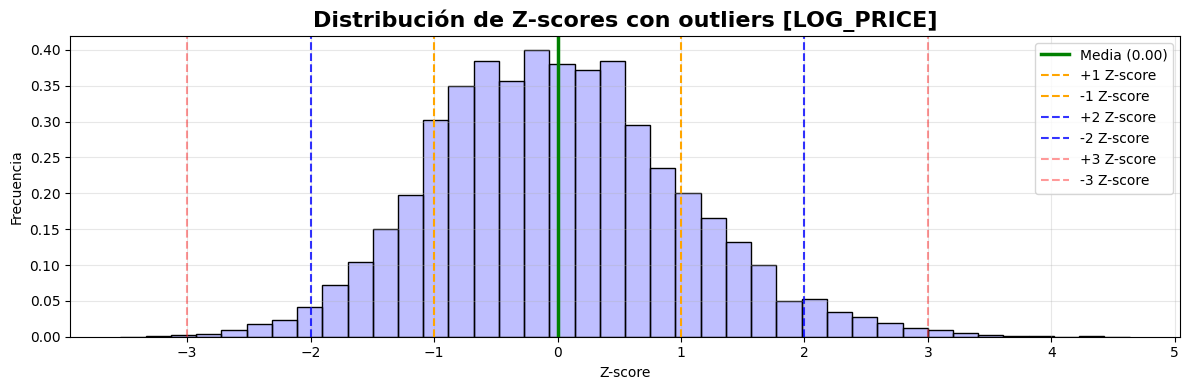


---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: 0.42 %  total outliers   807

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_PRICE`.
```
---


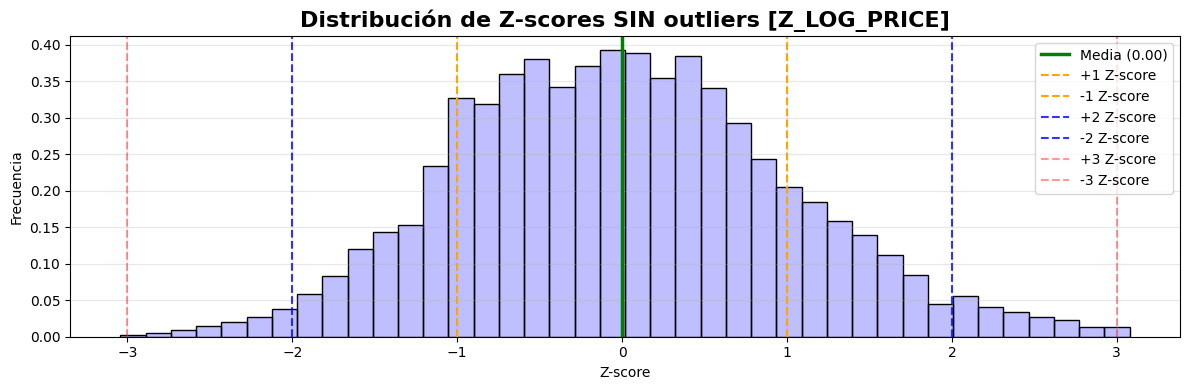


---
## 🚧 Análisis de outliers con z-score para `LOG_CONSTRUCTEDAREA`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: 27.43 %  total outliers   52098
- Entre z > 2 o z < -2: 5.44 %  total outliers   10333
- Entre z > 3 o z < -3: 0.77 %  total outliers   1461
---



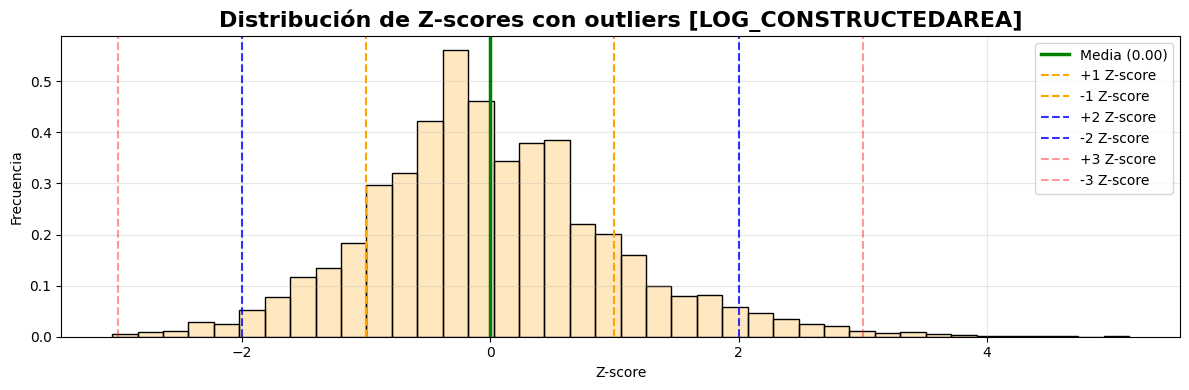


---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: 0.77 %  total outliers   1461

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_CONSTRUCTEDAREA`.
```
---


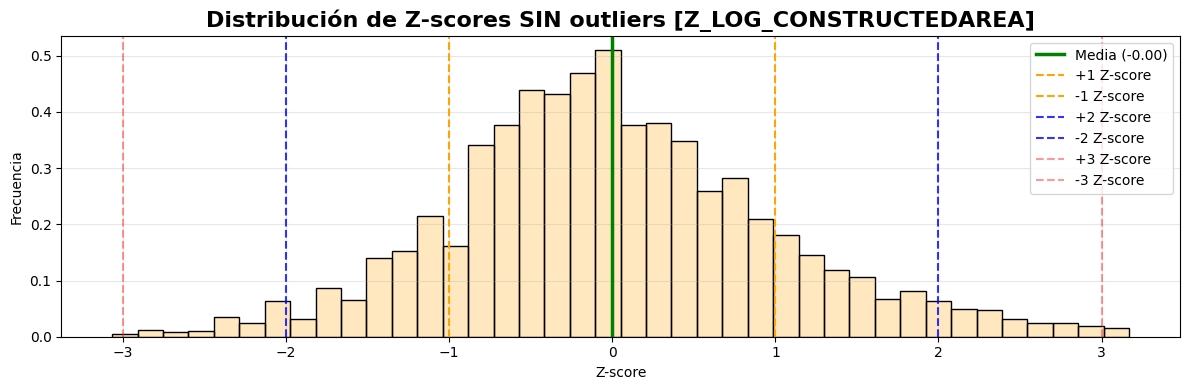


---
## 🚧 Análisis de outliers con z-score para `LOG_DISTANCE_TO_CITY_CENTER`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: 34.96 %  total outliers   66397
- Entre z > 2 o z < -2: 3.43 %  total outliers   6509
- Entre z > 3 o z < -3: 0.00 %  total outliers   1
---



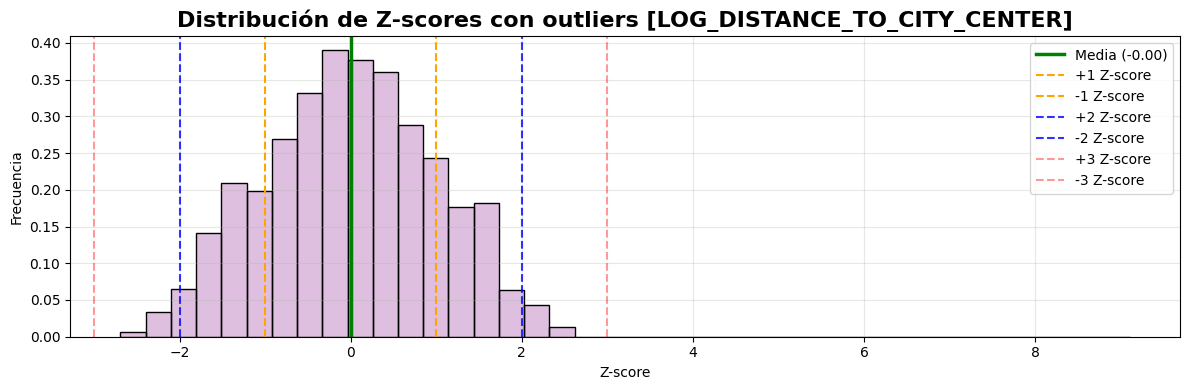


---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: 0.00 %  total outliers   1

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_DISTANCE_TO_CITY_CENTER`.
```
---


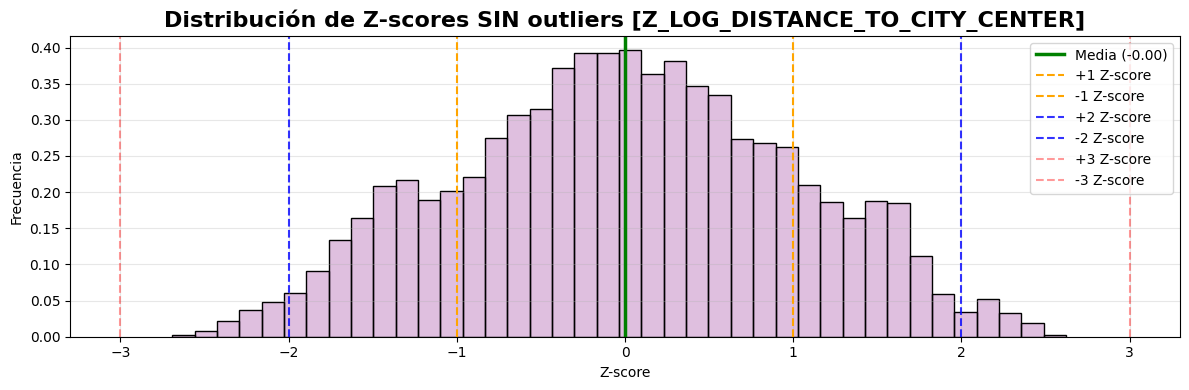


---
## 🚧 Análisis de outliers con z-score para `LOG_DISTANCE_TO_METRO`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: 19.54 %  total outliers   37108
- Entre z > 2 o z < -2: 4.64 %  total outliers   8807
- Entre z > 3 o z < -3: 1.42 %  total outliers   2689
---



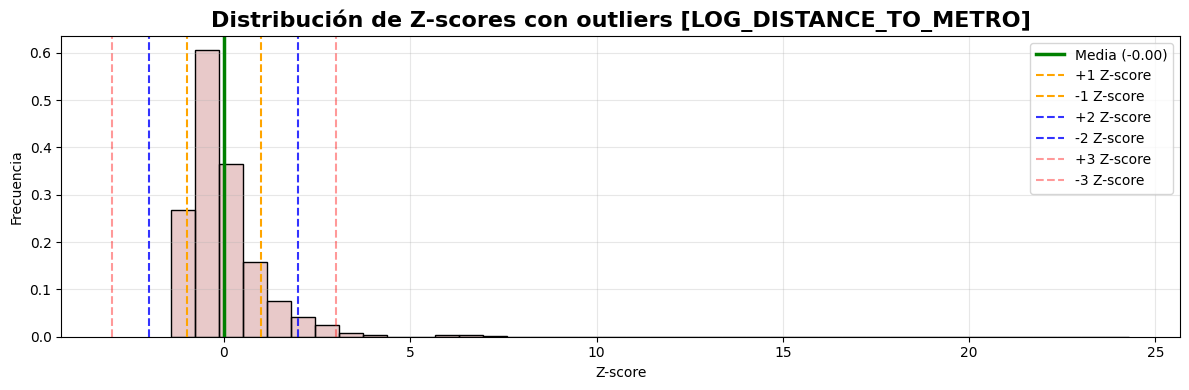


---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: 1.42 %  total outliers   2689

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_DISTANCE_TO_METRO`.
```
---


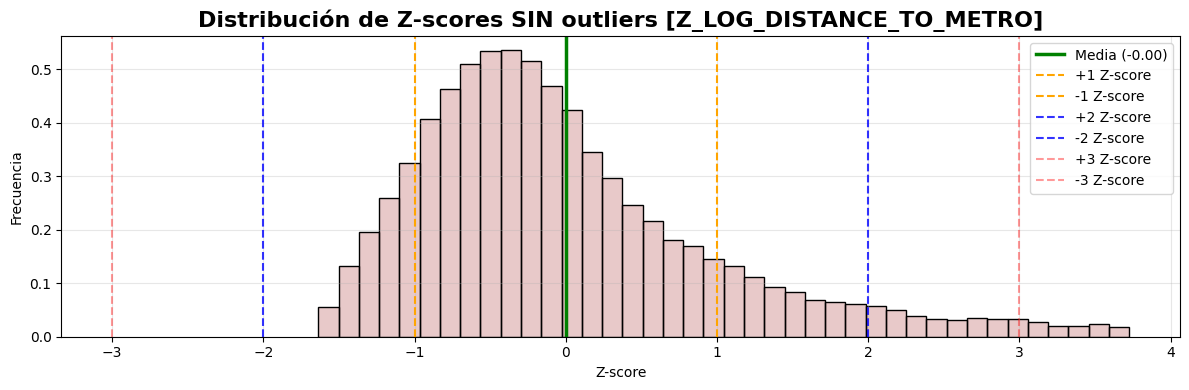

In [145]:
#zscore para la columna LOG_PRICE  y decidir cual de las dos es mejor para gestionar los outliers, si el metodo IQR o el metodo zscore.

# Analisis de Zscore para la columna LOG_PRICE.
#  
# Calculamos % de Zscores , para elegir cuanto % de outliers queremos eliminar.

precio = df_idealista_limpio["LOG_PRICE"]   
z_scores = (precio - precio.mean()) / precio.std()

# print("="*120)
# print("{:<40} [ LOG_PRICE ] {:<40}".format("", ""))
# print("="*120)
# print("-> Porcentaje y total outliers  con zscore para la columna [ LOG_PRICE ]")
# print("="*120)
# print(f"% Entre z > 1 o < -1 [ {(precio[(z_scores > 1) | (z_scores < -1)].shape[0]/precio.shape[0]*100):.2f}% ] total outliers [{(precio[(z_scores > 1) | (z_scores < -1)].shape[0])}]")
# print(f"% Entre z > 2 o < -2 [ {(precio[(z_scores > 2) | (z_scores < -2)].shape[0]/precio.shape[0]*100):.2f}% ] total outliers [{(precio[(z_scores > 2) | (z_scores < -2)].shape[0])}]")
# print(f"% Entre z > 3 o < -3 [ {(precio[(z_scores > 3) | (z_scores < -3)].shape[0]/precio.shape[0]*100):.2f}% ] total outliers [{(precio[(z_scores > 3) | (z_scores < -3)].shape[0])}]")
# print("="*120)

md = f"""
---
## 🚧 Análisis de outliers con z-score para `LOG_PRICE`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: {(precio[(z_scores > 1) | (z_scores < -1)].shape[0]/precio.shape[0]*100):.2f} %  total outliers   {(precio[(z_scores > 1) | (z_scores < -1)].shape[0])}
- Entre z > 2 o z < -2: {(precio[(z_scores > 2) | (z_scores < -2)].shape[0]/precio.shape[0]*100):.2f} %  total outliers   {(precio[(z_scores > 2) | (z_scores < -2)].shape[0])}
- Entre z > 3 o z < -3: {(precio[(z_scores > 3) | (z_scores < -3)].shape[0]/precio.shape[0]*100):.2f} %  total outliers   {(precio[(z_scores > 3) | (z_scores < -3)].shape[0])}
---

"""

display(Markdown(md))

plt.figure(figsize=(12, 4))

media = z_scores.mean()
std = z_scores.std()

# Histograma
sns.histplot(
             z_scores,
             bins = 40, 
             alpha = 0.25, 
             color= "blue", 
             edgecolor = "black",
             stat = "density"
            )

# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )

# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")

plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")

plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")

plt.title("Distribución de Z-scores con outliers [LOG_PRICE]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Gestionamos los outliers eliminando los valores con zscore > 3 o < -3, lo que corresponde a eliminar aproximadamente el 0.27% de los datos si la distribución es normal.
mask_outliers = (z_scores < 3) & (z_scores > -3)
precio_sin_outliers_zscore = precio[mask_outliers]  

# print("="*120)
# print("-> Elegimo el ","%"," Entre z > 3 o < -3  ")
# print("="*120)
# print(f"% Entre z > 3 o < -3 [ {(precio[(z_scores > 3) | (z_scores < -3)].shape[0]/precio.shape[0]*100):.2f}% ] total outliers [{(precio[(z_scores > 3) | (z_scores < -3)].shape[0])}]")
# print("-"*120)
# print("-> Grabamos nueva columna en df_idealista_limpio [ Z_LOG_PRICE ]")
# print("="*120)

md = f"""
---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: {(precio[(z_scores > 3) | (z_scores < -3)].shape[0]/precio.shape[0]*100):.2f} %  total outliers   {(precio[(z_scores > 3) | (z_scores < -3)].shape[0])}

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_PRICE`.
```
---
"""

display(Markdown(md))

# Asignamos los valores sin outliers a una nueva columna en el DataFrame.
df_idealista_limpio["Z_LOG_PRICE"] = precio_sin_outliers_zscore  

z_scores = (precio_sin_outliers_zscore - precio_sin_outliers_zscore.mean()) / precio_sin_outliers_zscore.std()

plt.figure(figsize=(12, 4))

media = z_scores.mean()
std = z_scores.std()

# Histograma
sns.histplot(
             z_scores,
             bins = 40, 
             alpha = 0.25, 
             color= "blue", 
             edgecolor = "black",
             stat = "density"
            )

# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )

# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")

plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")

plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")

plt.title("Distribución de Z-scores SIN outliers [Z_LOG_PRICE]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()

#"LOG_CONSTRUCTEDAREA", "LOG_DISTANCE_TO_CITY_CENTER", "LOG_DISTANCE_TO_METRO"]

# Analisis de Zscore para la columna LOG_CONSTRUCTEDAREA.
#  
# Calculamos % de Zscores , para elegir cuanto % de outliers queremos eliminar

area = df_idealista_limpio["LOG_CONSTRUCTEDAREA"]
z_scores_area = (area - area.mean()) / area.std()   


# print("="*120)
# print("{:<40} [ LOG_CONSTRUCTEDAREA ] {:<40}".format("", ""))
# print("="*120)
# print("-> Porcentaje y total outliers  con zscore para la columna [ LOG_CONSTRUCTEDAREA ]")
# print("="*120)
# print(f"% Entre z > 1 o < -1 [ {(area[(z_scores_area > 1) | (z_scores_area < -1)].shape[0]/area.shape[0]*100):.2f}% ] total outliers [{(area[(z_scores_area > 1) | (z_scores_area < -1)].shape[0])}]")
# print(f"% Entre z > 2 o < -2 [ {(area[(z_scores_area > 2) | (z_scores_area < -2)].shape[0]/area.shape[0]*100):.2f}% ] total outliers [{(area[(z_scores_area > 2) | (z_scores_area < -2)].shape[0])}]")
# print(f"% Entre z > 3 o < -3 [ {(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0]/area.shape[0]*100):.2f}% ] total outliers [{(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0])}]")
# print("="*120)

md = f"""
---
## 🚧 Análisis de outliers con z-score para `LOG_CONSTRUCTEDAREA`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: {(area[(z_scores_area > 1) | (z_scores_area < -1)].shape[0]/area.shape[0]*100):.2f} %  total outliers   {(area[(z_scores_area > 1) | (z_scores_area < -1)].shape[0])}
- Entre z > 2 o z < -2: {(area[(z_scores_area > 2) | (z_scores_area < -2)].shape[0]/area.shape[0]*100):.2f} %  total outliers   {(area[(z_scores_area > 2) | (z_scores_area < -2)].shape[0])}
- Entre z > 3 o z < -3: {(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0]/area.shape[0]*100):.2f} %  total outliers   {(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0])}
---

"""

display(Markdown(md))


plt.figure(figsize=(12, 4))
media = z_scores_area.mean()
std = z_scores_area.std()
# Histograma
sns.histplot(
             z_scores_area,
             bins = 40, 
             alpha = 0.25, 
             color= "orange",
             edgecolor = "black",
             stat = "density"
            )       
# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )
# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")
plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")
plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")
plt.title("Distribución de Z-scores con outliers [LOG_CONSTRUCTEDAREA]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()  


# Gestionamos los outliers eliminando los valores con zscore > 3 o < -3, lo que corresponde a eliminar aproximadamente el 0.27% de los datos si la distribución es normal.
mask_outliers_area = (z_scores_area < 3) & (z_scores_area > -3)
area_sin_outliers_zscore = area[mask_outliers_area] 

# print("="*120)
# print("-> Elegimo el ","%"," Entre z > 3 o < -3  ")
# print("="*120)
# print(f"% Entre z > 3 o < -3 [ {(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0]/area.shape[0]*100):.2f}% ] total outliers [{(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0])}]")
# print("-"*120)
# print("-> Grabamos nueva columna en df_idealista_limpio [ Z_LOG_CONSTRUCTEDAREA ]")
# print("="*120)

md = f"""
---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: {(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0]/area.shape[0]*100):.2f} %  total outliers   {(area[(z_scores_area > 3) | (z_scores_area < -3)].shape[0])}

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_CONSTRUCTEDAREA`.
```
---
"""

display(Markdown(md))

df_idealista_limpio["Z_LOG_CONSTRUCTEDAREA"] = area_sin_outliers_zscore
z_scores_area = (area_sin_outliers_zscore - area_sin_outliers_zscore.mean()) / area_sin_outliers_zscore.std()

plt.figure(figsize=(12, 4))
media = z_scores_area.mean()
std = z_scores_area.std()
# Histograma
sns.histplot(
             z_scores_area,
             bins = 40, 
             alpha = 0.25, 
             color= "orange",
             edgecolor = "black",
             stat = "density"
            )
# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )
# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")
plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")
plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")
plt.title("Distribución de Z-scores SIN outliers [Z_LOG_CONSTRUCTEDAREA]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()  

# Analisis de Zscore para la columna LOG_DISTANCE_TO_CITY_CENTER.
#
# Calculamos % de Zscores , para elegir cuanto % de outliers queremos eliminar

distancia_centro = df_idealista_limpio["LOG_DISTANCE_TO_CITY_CENTER"]
z_scores_distancia_centro = (distancia_centro - distancia_centro.mean()) / distancia_centro.std()

# print("="*120)
# print("{:<40} [ LOG_DISTANCE_TO_CITY_CENTER ] {:<40}".format("", ""))
# print("="*120)
# print("-> Porcentaje y total outliers  con zscore para la columna [ LOG_DISTANCE_TO_CITY_CENTER ]")
# print("="*120)
# print(f"% Entre z > 1 o < -1 [ {(distancia_centro[(z_scores_distancia_centro > 1) | (z_scores_distancia_centro < -1)].shape[0]/distancia_centro.shape[0]*100):.2f}% ] total outliers [{(distancia_centro[(z_scores_distancia_centro > 1) | (z_scores_distancia_centro < -1)].shape[0])}]")
# print(f"% Entre z > 2 o < -2 [ {(distancia_centro[(z_scores_distancia_centro > 2) | (z_scores_distancia_centro < -2)].shape[0]/distancia_centro.shape[0]*100):.2f}% ] total outliers [{(distancia_centro[(z_scores_distancia_centro > 2) | (z_scores_distancia_centro < -2)].shape[0])}]")
# print(f"% Entre z > 3 o < -3 [ {(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0]/distancia_centro.shape[0]*100):.2f}% ] total outliers [{(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0])}]")
# print("="*120)  

md = f"""
---
## 🚧 Análisis de outliers con z-score para `LOG_DISTANCE_TO_CITY_CENTER`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: {(distancia_centro[(z_scores_distancia_centro > 1) | (z_scores_distancia_centro < -1)].shape[0]/distancia_centro.shape[0]*100):.2f} %  total outliers   {(distancia_centro[(z_scores_distancia_centro > 1) | (z_scores_distancia_centro < -1)].shape[0])}
- Entre z > 2 o z < -2: {(distancia_centro[(z_scores_distancia_centro > 2) | (z_scores_distancia_centro < -2)].shape[0]/distancia_centro.shape[0]*100):.2f} %  total outliers   {(distancia_centro[(z_scores_distancia_centro > 2) | (z_scores_distancia_centro < -2)].shape[0])}
- Entre z > 3 o z < -3: {(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0]/distancia_centro.shape[0]*100):.2f} %  total outliers   {(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0])}
---

"""

display(Markdown(md))

plt.figure(figsize=(12, 4))
media = z_scores_distancia_centro.mean()
std = z_scores_distancia_centro.std()
# Histograma
sns.histplot(
             z_scores_distancia_centro,
             bins = 40, 
             alpha = 0.25, 
             color= "purple",
             edgecolor = "black",
             stat = "density"
            )
# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )
# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")
plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")
plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")
plt.title("Distribución de Z-scores con outliers [LOG_DISTANCE_TO_CITY_CENTER]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()  
# Gestionamos los outliers eliminando los valores con zscore > 3 o < -3, lo que corresponde a eliminar aproximadamente el 0.27% de los datos si la distribución es normal.
mask_outliers_distancia_centro = (z_scores_distancia_centro < 3) & (z_scores_distancia_centro > -3)
distancia_centro_sin_outliers_zscore = distancia_centro[mask_outliers_distancia_centro]     

# print("="*120)
# print("-> Elegimo el ","%"," Entre z > 3 o < -3  ")
# print("="*120)
# print(f"% Entre z > 3 o < -3 [ {(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0]/distancia_centro.shape[0]*100):.2f}% ] total outliers [{(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0])}]")
# print("-"*120)
# print("-> Grabamos nueva columna en df_idealista_limpio [ Z_LOG_DISTANCE_TO_CITY_CENTER ]")
# print("="*120)  

md = f"""
---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: {(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0]/distancia_centro.shape[0]*100):.2f} %  total outliers   {(distancia_centro[(z_scores_distancia_centro > 3) | (z_scores_distancia_centro < -3)].shape[0])}

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_DISTANCE_TO_CITY_CENTER`.
```
---
"""

display(Markdown(md))

df_idealista_limpio["Z_LOG_DISTANCE_TO_CITY_CENTER"] = distancia_centro_sin_outliers_zscore
z_scores_distancia_centro = (distancia_centro_sin_outliers_zscore - distancia_centro_sin_outliers_zscore.mean()) / distancia_centro_sin_outliers_zscore.std()   
plt.figure(figsize=(12, 4))
media = z_scores_distancia_centro.mean()
std = z_scores_distancia_centro.std()
# Histograma
sns.histplot(
             z_scores_distancia_centro,
             bins = 40, 
             alpha = 0.25, 
             color= "purple",
             edgecolor = "black",
             stat = "density"
            )
# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )
# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")
plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")
plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")
plt.title("Distribución de Z-scores SIN outliers [Z_LOG_DISTANCE_TO_CITY_CENTER]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()  

# Analisis de Zscore para la columna LOG_DISTANCE_TO_METRO.
# Calculamos % de Zscores , para elegir cuanto % de outliers queremos eliminar
distancia_metro = df_idealista_limpio["LOG_DISTANCE_TO_METRO"]
z_scores_distancia_metro = (distancia_metro - distancia_metro.mean()) / distancia_metro.std()

# print("="*120)
# print("{:<40} [ LOG_DISTANCE_TO_METRO ] {:<40}".format("", ""))
# print("="*120)
# print("-> Porcentaje y total outliers  con zscore para la columna [ LOG_DISTANCE_TO_METRO ]")
# print("="*120)
# print(f"% Entre z > 1 o < -1 [ {(distancia_metro[(z_scores_distancia_metro > 1) | (z_scores_distancia_metro < -1)].shape[0]/distancia_metro.shape[0]*100):.2f}% ] total outliers [{(distancia_metro[(z_scores_distancia_metro > 1) | (z_scores_distancia_metro < -1)].shape[0])}]")
# print(f"% Entre z > 2 o < -2 [ {(distancia_metro[(z_scores_distancia_metro > 2) | (z_scores_distancia_metro < -2)].shape[0]/distancia_metro.shape[0]*100):.2f}% ] total outliers [{(distancia_metro[(z_scores_distancia_metro > 2) | (z_scores_distancia_metro < -2)].shape[0])}]")
# print(f"% Entre z > 3 o < -3 [ {(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0]/distancia_metro.shape[0]*100):.2f}% ] total outliers [{(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0])}]")
# print("="*120)

md = f"""
---
## 🚧 Análisis de outliers con z-score para `LOG_DISTANCE_TO_METRO`
---
**Porcentaje y total de outliers:**

- Entre z > 1 o z < -1: {(distancia_metro[(z_scores_distancia_metro > 1) | (z_scores_distancia_metro < -1)].shape[0]/distancia_metro.shape[0]*100):.2f} %  total outliers   {(distancia_metro[(z_scores_distancia_metro > 1) | (z_scores_distancia_metro < -1)].shape[0])}
- Entre z > 2 o z < -2: {(distancia_metro[(z_scores_distancia_metro > 2) | (z_scores_distancia_metro < -2)].shape[0]/distancia_metro.shape[0]*100):.2f} %  total outliers   {(distancia_metro[(z_scores_distancia_metro > 2) | (z_scores_distancia_metro < -2)].shape[0])}
- Entre z > 3 o z < -3: {(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0]/distancia_metro.shape[0]*100):.2f} %  total outliers   {(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0])}
---

"""

display(Markdown(md))

plt.figure(figsize=(12, 4))
media = z_scores_distancia_metro.mean()
std = z_scores_distancia_metro.std()
# Histograma
sns.histplot(
             z_scores_distancia_metro,
             bins = 40, 
             alpha = 0.25, 
             color= "brown",
             edgecolor = "black",
             stat = "density"
            )
# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )
# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")
plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")
plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")
plt.title("Distribución de Z-scores con outliers [LOG_DISTANCE_TO_METRO]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Gestionamos los outliers eliminando los valores con zscore > 3 o < -3, lo que corresponde a eliminar aproximadamente el 0.27% de los datos si la distribución es normal.
mask_outliers_distancia_metro = (z_scores_distancia_metro < 3) & (z_scores_distancia_metro > -3)
distancia_metro_sin_outliers_zscore = distancia_metro[mask_outliers_distancia_metro]     

# print("="*120)
# print("-> Elegimo el ","%"," Entre z > 3 o < -3  ")
# print("="*120)
# print(f"% Entre z > 3 o < -3 [ {(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0]/distancia_metro.shape[0]*100):.2f}% ] total outliers [{(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0])}]")
# print("-"*120)
# print("-> Grabamos nueva columna en df_idealista_limpio [ Z_LOG_DISTANCE_TO_METRO ]")
# print("="*120)

md = f"""
---

### Selección de umbral de z-score

Elegimos el **% entre z > 3 o z < -3** para definir outliers.

- Entre z > 3 o z < -3: {(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0]/distancia_metro.shape[0]*100):.2f} %  total outliers   {(distancia_metro[(z_scores_distancia_metro > 3) | (z_scores_distancia_metro < -3)].shape[0])}

---
```text
➡️ Grabamos nueva columna en `df_idealista_limpio` llamada `Z_LOG_DISTANCE_TO_METRO`.
```
---
"""

display(Markdown(md))

df_idealista_limpio["Z_LOG_DISTANCE_TO_METRO"] = distancia_metro_sin_outliers_zscore
z_scores_distancia_metro = (distancia_metro_sin_outliers_zscore - distancia_metro_sin_outliers_zscore.mean()) / distancia_metro_sin_outliers_zscore.std()

plt.figure(figsize=(12, 4))

media = z_scores_distancia_metro.mean()
std = z_scores_distancia_metro.std()

# Histograma
sns.histplot(
             z_scores_distancia_metro,
             bins = 40, 
             alpha = 0.25, 
             color= "brown",
             edgecolor = "black",
             stat = "density"
            )
# Media en verde
plt.axvline(
             media,
             color = "green",
             linestyle = "-",
             linewidth = 2.5,
             label = f"Media ({media:.2f})"
            )
# Líneas ±1, ±2, ±3 desviaciones típicas
plt.axvline(media + 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="+1 Z-score")
plt.axvline(media - 1*std, color = "orange", linestyle = "--", alpha = 1.0, label ="-1 Z-score")
plt.axvline(media + 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "+2 Z-score")
plt.axvline(media - 2*std, color = "blue", linestyle = "--", alpha = 0.8, label = "-2 Z-score")
plt.axvline(media + 3*std, color ="red", linestyle ="--", alpha = 0.4, label = "+3 Z-score")
plt.axvline(media - 3*std, color ="red", linestyle ="--", alpha = 0.4, label ="-3 Z-score")
plt.title("Distribución de Z-scores SIN outliers [Z_LOG_DISTANCE_TO_METRO]", fontsize = 16, fontweight = "bold")
plt.xlabel("Z-score")
plt.ylabel("Frecuencia")
plt.grid(alpha = 0.3)
plt.legend()
plt.tight_layout()
plt.show()  



---
```text
➡️ Analisis mapa de calor
PRICE, CONSTRUCTEDAREA, BATHNUMBER, ROOMNUMBER, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO, HASLIFT, LATITUDE, LONGITUDE, CADCONSTRUCTIONYEAR 
```
---


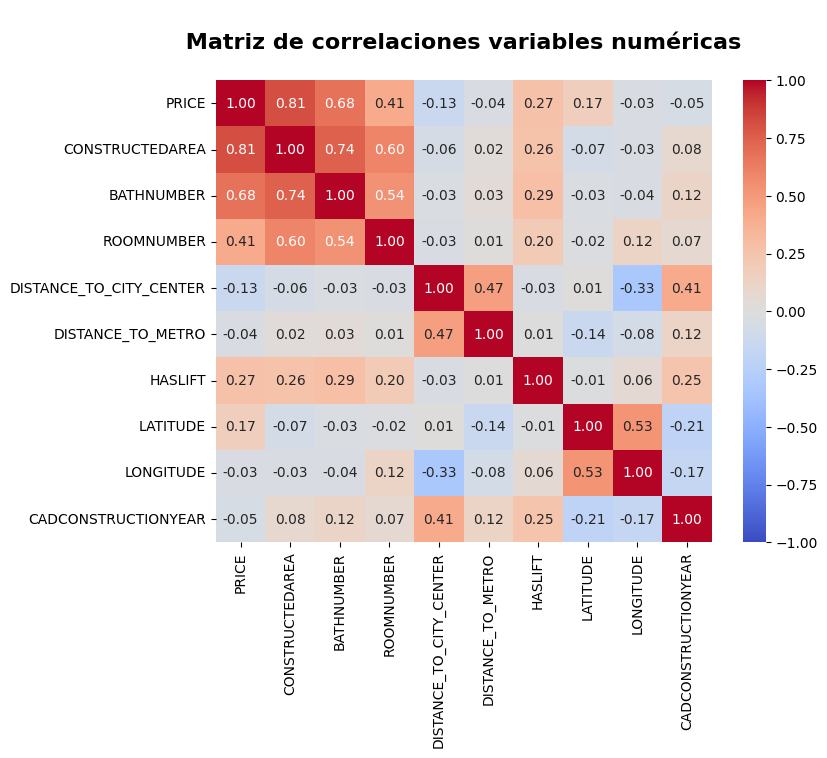


---

## Conclusiones del análisis de correlación entre columnas numéricas

- Vemos que se relacionan el **precio**, el **área construida**, la **cantidad de habitaciones** y la **cantidad de baños**.
- Podemos decir que la relación de más fuerte a menos fuerte es:

  1. Precio  
  2. Área construida  
  3. Cantidad de baños  
  4. Cantidad de habitaciones  

- Los **años de construcción** tienen relación con la **distancia al centro de la ciudad**.  
  No es tan fuerte, pero nos podría servir.

---


In [166]:
# Matriz de correlacion para ver la relacion entre columnas numericas

# print("="*200)
# print(f"--> Analisis mapa de calor {lista_correlacion_columnas_num} ")
# print("="*200)
# print("\n")

md = f"""
---
```text
➡️ Analisis mapa de calor
{", ".join(lista_correlacion_columnas_num)} 
```
---
"""
display(Markdown(md))

df_correlacion: pd.DataFrame = df_idealista_limpio[lista_correlacion_columnas_num].corr()
plt.figure(figsize=(8,6))
sns.heatmap(df_correlacion, 
            annot  = True, 
            cmap   = "coolwarm",
            fmt    = ".2f",
            vmax   = 1, 
            vmin   = -1,
            center = 0)

plt.title("\n Matriz de correlaciones variables numéricas \n    ", fontsize=16, fontweight="bold")
plt.show()

# print("="*150)
# print(" -> Conclusiones del análisis de correlacion entre las columnas numericas")
# print("="*150)
# print(" - Vemos que se relacionan el precio, area contruida, cantidas de habitaciones y de baños")
# print(" - Podemos decir que la relacion de mas fuerte a menos fuerte es :")
# print("   1. Precio")
# print("   2. Area construida")
# print("   3. Cantidad de baños")
# print("   4. Cantidad de habitaciones")
# print(" -> Los años de construccion tiene relacion con la distancia al centro de la ciudad")
# print("    no es tan fuerte pero nos podria servir")
# print("="*150)
# print("\n")

md = """
---

## Conclusiones del análisis de correlación entre columnas numéricas

- Vemos que se relacionan el **precio**, el **área construida**, la **cantidad de habitaciones** y la **cantidad de baños**.
- Podemos decir que la relación de más fuerte a menos fuerte es:

  1. Precio  
  2. Área construida  
  3. Cantidad de baños  
  4. Cantidad de habitaciones  

- Los **años de construcción** tienen relación con la **distancia al centro de la ciudad**.  
  No es tan fuerte, pero nos podría servir.

---
"""

display(Markdown(md))



---
```text
➡️ Analisis mapa de calor
PRICE, CONSTRUCTEDAREA, BATHNUMBER, ROOMNUMBER, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO, HASLIFT, LATITUDE, LONGITUDE, CADCONSTRUCTIONYEAR, LOG_PRICE, LOG_CONSTRUCTEDAREA, LOG_DISTANCE_TO_CITY_CENTER, LOG_DISTANCE_TO_METRO 
```
---


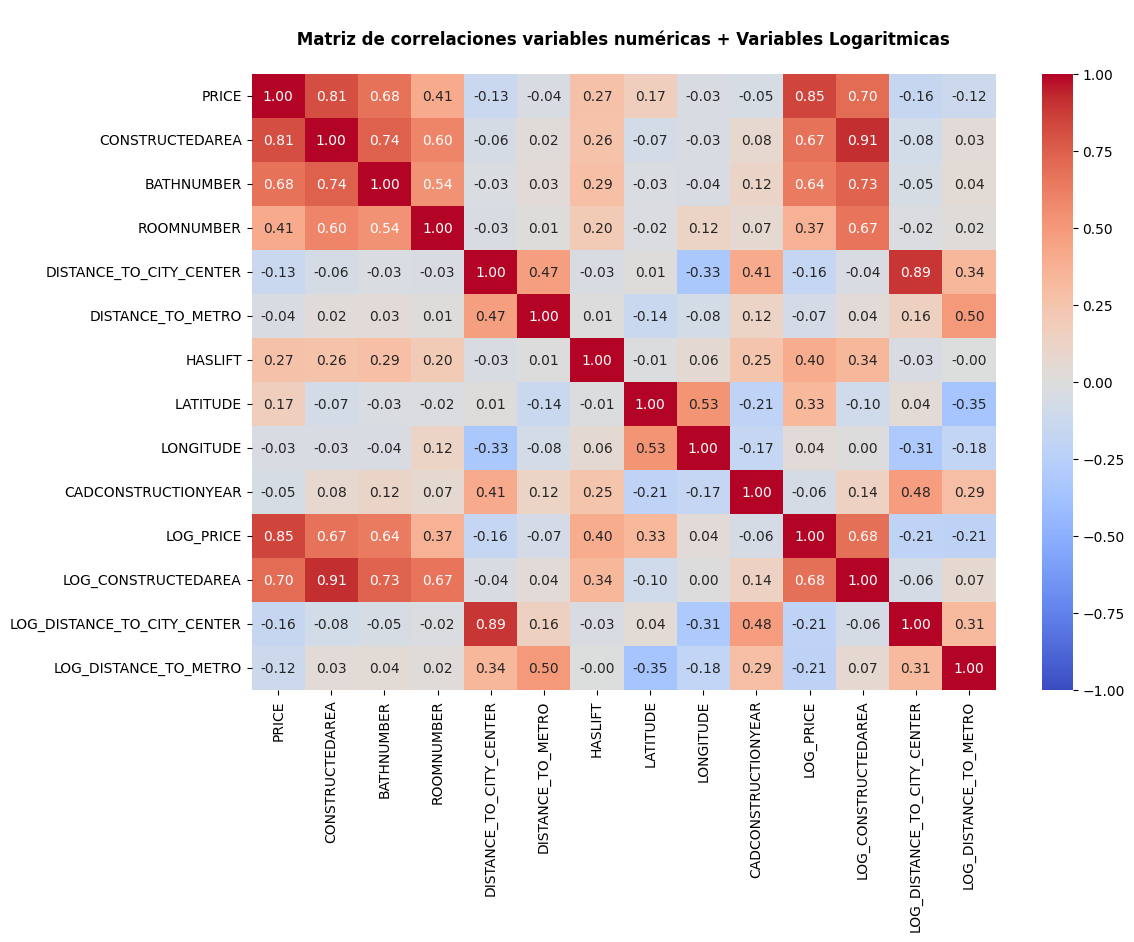

In [163]:
# utilizar normalizadas ["LOG_PRICE", "LOG_CONSTRUCTEDAREA", "LOG_DISTANCE_TO_CITY_CENTER", "LOG_DISTANCE_TO_METRO"] para ver la relacion entre el precio y el area construida con una escala logaritmica para ver si hay una relacion mas clara entre ellas.
lista_correlacion_columnas_num_log = ["PRICE", "CONSTRUCTEDAREA", "BATHNUMBER", "ROOMNUMBER","DISTANCE_TO_CITY_CENTER","DISTANCE_TO_METRO","HASLIFT","LATITUDE","LONGITUDE","CADCONSTRUCTIONYEAR",
                                      "LOG_PRICE", "LOG_CONSTRUCTEDAREA", "LOG_DISTANCE_TO_CITY_CENTER", "LOG_DISTANCE_TO_METRO"]

# print("="*300)
# print(f"--> Analisis mapa de calor {lista_correlacion_columnas_num_log} ")
# print("="*300)
# print("\n")

md = f"""
---
```text
➡️ Analisis mapa de calor
{", ".join(lista_correlacion_columnas_num_log)} 
```
---
"""
display(Markdown(md))

df_correlacion: pd.DataFrame = df_idealista_limpio[lista_correlacion_columnas_num_log].corr()
plt.figure(figsize=(12,8))
sns.heatmap(df_correlacion, 
            annot  = True, 
            cmap   = "coolwarm",
            fmt    = ".2f",
            vmax   = 1, 
            vmin   = -1,
            center = 0)

plt.title("\n Matriz de correlaciones variables numéricas + Variables Logaritmicas \n", fontsize = 12, fontweight = "bold")
plt.show()

# print("="*150)
# print(" -> Conclusiones del análisis de correlacion entre las columnas numericas")
# print("="*150)
# print(" - Vemos que se relacionan el precio, area contruida, cantidas de habitaciones y de baños")
# print(" - Podemos decir que la relacion de mas fuerte a menos fuerte es :")
# print("   1. Precio")
# print("   2. Area construida")
# print("   3. Cantidad de baños")
# print("   4. Cantidad de habitaciones")
# print(" -> Los años de construccion tiene relacion con la distancia al centro de la ciudad")
# print("    no es tan fuerte pero nos podria servir")
# print("="*150)
# print("\n")



---

```text
➡️ Analisis mapa de calor
PRICE, CONSTRUCTEDAREA, BATHNUMBER, ROOMNUMBER, DISTANCE_TO_CITY_CENTER, DISTANCE_TO_METRO, HASLIFT, LATITUDE, LONGITUDE, CADCONSTRUCTIONYEAR, LOG_PRICE, LOG_CONSTRUCTEDAREA, LOG_DISTANCE_TO_CITY_CENTER, LOG_DISTANCE_TO_METRO, Z_LOG_PRICE, Z_LOG_CONSTRUCTEDAREA, Z_LOG_DISTANCE_TO_CITY_CENTER, Z_LOG_DISTANCE_TO_METRO 
```
---


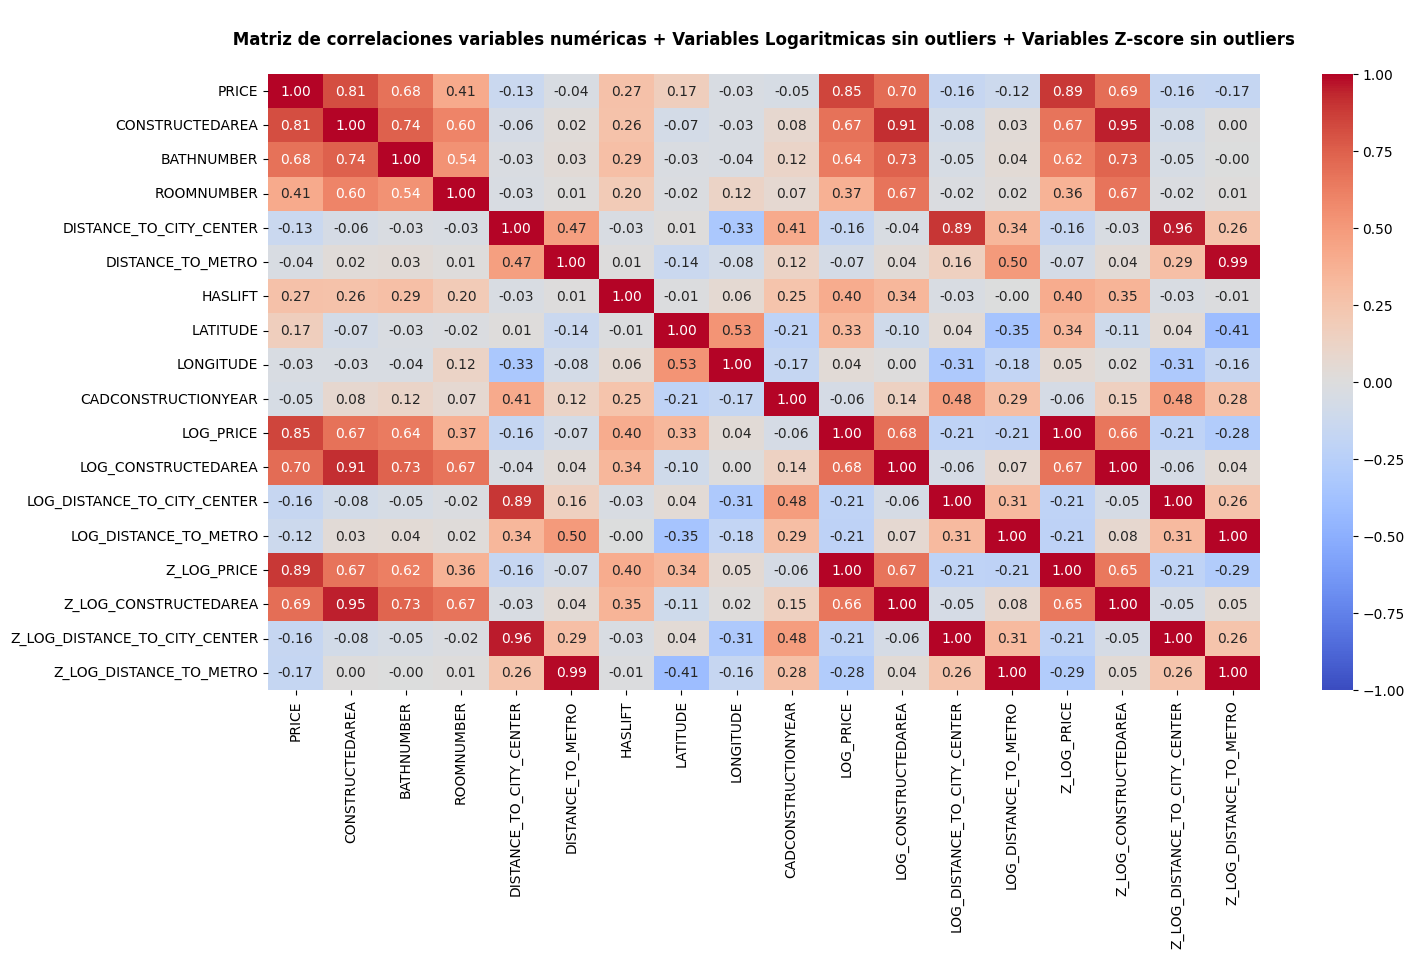

In [162]:
# utilizar normalizadas sin outliers ["Z_LOG_PRICE", "Z_LOG_CONSTRUCTEDAREA", "Z_LOG_DISTANCE_TO_CITY_CENTER", "Z_LOG_DISTANCE_TO_METRO"] para ver la relacion entre el precio y el area construida con una escala logaritmica para ver si hay una relacion mas clara entre ellas.
lista_correlacion_columnas_num_log_sin_outliers = ["PRICE", "CONSTRUCTEDAREA", "BATHNUMBER", "ROOMNUMBER","DISTANCE_TO_CITY_CENTER","DISTANCE_TO_METRO","HASLIFT","LATITUDE","LONGITUDE","CADCONSTRUCTIONYEAR",
                                                   "LOG_PRICE", "LOG_CONSTRUCTEDAREA", "LOG_DISTANCE_TO_CITY_CENTER", "LOG_DISTANCE_TO_METRO",
                                                   "Z_LOG_PRICE", "Z_LOG_CONSTRUCTEDAREA", "Z_LOG_DISTANCE_TO_CITY_CENTER", "Z_LOG_DISTANCE_TO_METRO"]

# print("="*400)
# print(f"--> Analisis mapa de calor {lista_correlacion_columnas_num_log_sin_outliers} ")
# print("="*400)
# print("\n")

md = f"""
---

```text
➡️ Analisis mapa de calor
{", ".join(lista_correlacion_columnas_num_log_sin_outliers)} 
```
---
"""
display(Markdown(md))

df_correlacion: pd.DataFrame = df_idealista_limpio[lista_correlacion_columnas_num_log_sin_outliers].corr()
plt.figure(figsize=(16,8))
sns.heatmap(df_correlacion, 
            annot  = True, 
            cmap   = "coolwarm",
            fmt    = ".2f",
            vmax   = 1, 
            vmin   = -1,
            center = 0)

plt.title("\n Matriz de correlaciones variables numéricas + Variables Logaritmicas sin outliers + Variables Z-score sin outliers \n", fontsize=12, fontweight="bold")
plt.show()

# print("="*150)
# print(" -> Conclusiones del análisis de correlacion entre las columnas numericas")
# print("="*150)
# print(" - Vemos que se relacionan el precio, area contruida, cantidas de habitaciones y de baños")
# print(" - Podemos decir que la relacion de mas fuerte a menos fuerte es :")
# print("   1. Precio")
# print("   2. Area construida")
# print("   3. Cantidad de baños")
# print("   4. Cantidad de habitaciones")
# print(" -> Los años de construccion tiene relacion con la distancia al centro de la ciudad")
# print("    no es tan fuerte pero nos podria servir")
# print("="*150)
# print("\n")



---

➡️ Graficas de dispersion [ `PRICE , CONSTRUCTEDAREA`]  con categorias [ `bin_tipo_acabado` ]

---


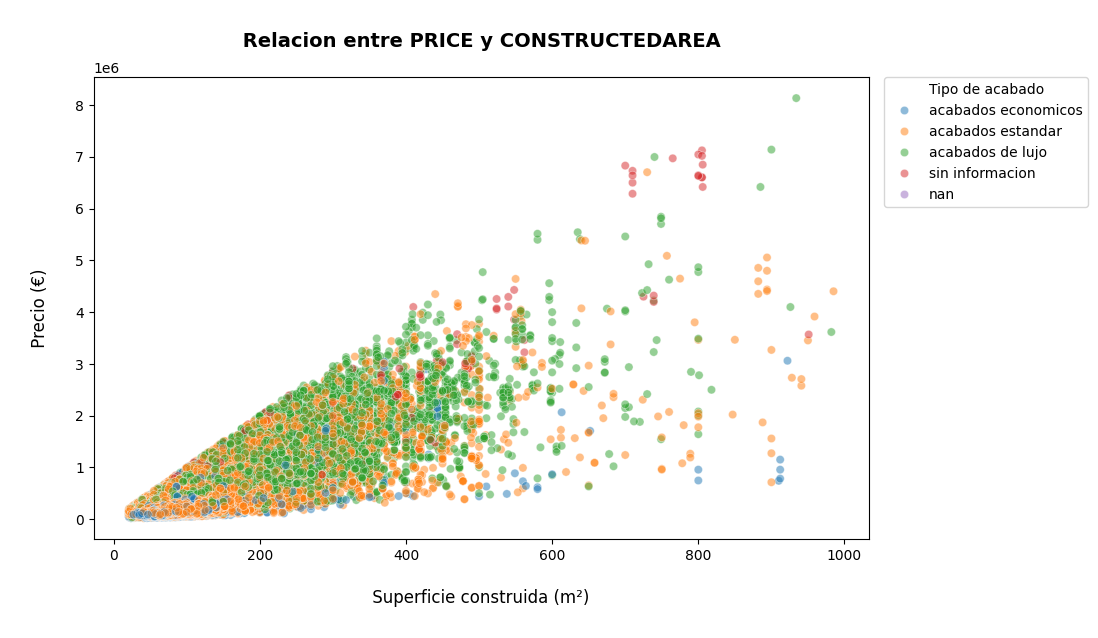

In [155]:
# Graficas de dispersion para ver la relacion entre las columnas numericas y categoricas.

# print("="*150)
# print("--> Graficas de dispersion [ PRICE , CONSTRUCTEDAREA]  con categorias [ bin_tipo_acabado ]")
# print("="*150)
# print("\n")

md = """
---

➡️ Graficas de dispersion [ `PRICE , CONSTRUCTEDAREA`]  con categorias [ `bin_tipo_acabado` ]

---
"""
display(Markdown(md))

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df_idealista_limpio,
    x="CONSTRUCTEDAREA",
    y="PRICE",
    hue="bin_tipo_acabado",
    alpha=0.5,
    ax=ax
)

ax.set_title("\n Relacion entre PRICE y CONSTRUCTEDAREA \n", fontsize = 14, fontweight = "bold")
ax.set_xlabel("\n Superficie construida (m²) \n", fontsize = 12)
ax.set_ylabel("\n Precio (€) \n", fontsize =12)


handles, labels = ax.get_legend_handles_labels()
ax.legend(
    title = "Tipo de acabado",
    bbox_to_anchor = (1.02, 1),
    loc = "upper left",
    borderaxespad = 0.
)

plt.show()


---

➡️ Graficas de dispersion [ `LOG_CONSTRUCTEDAREA , LOG_PRICE`]  con categorias [ `bin_tipo_acabado` ]
   Aplicamos logaritmo para ver relacion clara entre valores y reducir el efecto de los outliers

---


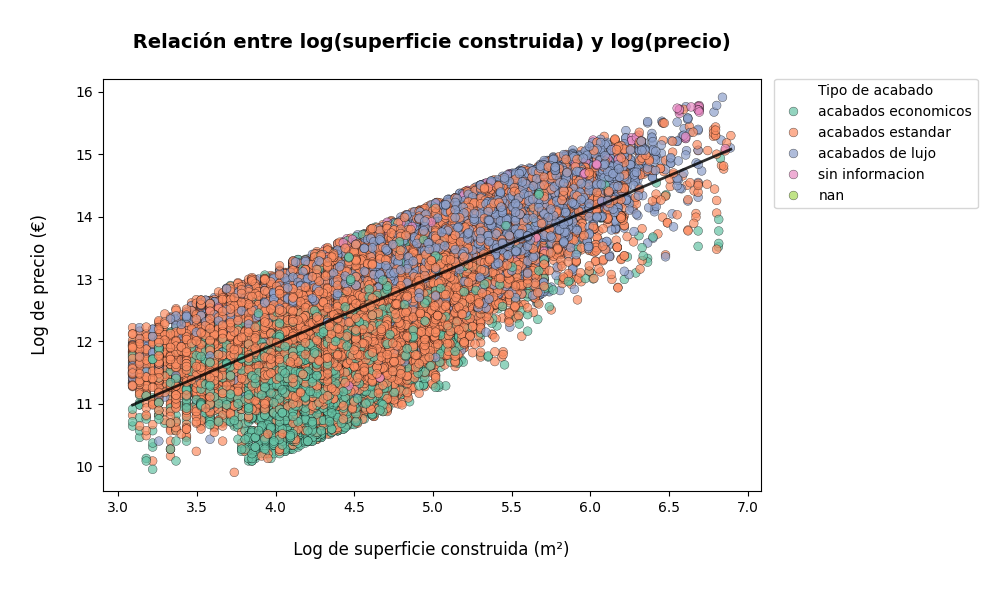


---
## Conclusiones de las gráficas de dispersión  
---

**Variables:** `LOG_CONSTRUCTEDAREA` vs `LOG_PRICE`  
**Categoría:** `bin_tipo_acabado`

- Los acabados **de lujo** tienen precios más altos y superficies construidas más grandes.  
- Los acabados **estándar** tienen precios y superficies construidas intermedias.  
- Los acabados **económicos** tienen precios más bajos y superficies construidas más pequeñas.  

- Se observa una **relación positiva** entre el logaritmo de la superficie construida y el logaritmo del precio,  
  lo que indica que a medida que aumenta la superficie construida, el precio tiende a aumentar.

---


In [159]:


# print("="*150)
# print(" --> Graficas de dispersion [ LOG_CONSTRUCTEDAREA, LOG_PRICE ] con categorias [ bin_tipo_acabado ]")
# print("     aplicamos logaritmo para ver relacion clara entre valores y reducir el efecto de los outliers")
# print("="*150)
# print("\n")

md = """
---

➡️ Graficas de dispersion [ `LOG_CONSTRUCTEDAREA , LOG_PRICE`]  con categorias [ `bin_tipo_acabado` ]
   Aplicamos logaritmo para ver relacion clara entre valores y reducir el efecto de los outliers

---
"""
display(Markdown(md))

fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
                data = df_idealista_limpio,
                x = "LOG_CONSTRUCTEDAREA",
                y = "LOG_PRICE",
                hue = "bin_tipo_acabado",
                palette = "Set2",
                alpha = 0.7,
                s = 40,
                edgecolor = "black",
                linewidth = 0.3,
                ax = ax
               )

# Línea de tendencia global
sns.regplot(
            data = df_idealista_limpio,
            x = "LOG_CONSTRUCTEDAREA",
            y = "LOG_PRICE",
            scatter = False,
            color = "black",
            line_kws = {"linewidth": 2, "alpha": 0.8},
            ax = ax
  )

ax.set_title("\n Relación entre log(superficie construida) y log(precio) \n", fontsize=14, fontweight="bold")
ax.set_xlabel("\n Log de superficie construida (m²) \n", fontsize=12)
ax.set_ylabel("\n Log de precio (€) \n", fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
          title = "Tipo de acabado",
          bbox_to_anchor = (1.02, 1),
          loc = "upper left",
          borderaxespad = 0.
         ) 

plt.tight_layout()
plt.show()

# print("\n")
# print("="*150)
# print(" -> Conclusiones de las Graficas de dispersion [ LOG_CONSTRUCTEDAREA, LOG_PRICE ] con categorias [ bin_tipo_acabado ]" )
# print("="*150)
# print(" - Vemos que los acabados de lujo tienen precios mas altos y superifices construidas mas grandes," )
# print("   los acabados estandar tienen precios y superficies construidas intermedias,")
# print("   y los acabados economicos tienen precios mas bajos y superficies construidas mas pequeñas")
# print(" - Vemos una relacion positiva entre el logaritmo de la superficie construida y el logaritmo del precio,")
# print("   lo que indica que a medida que aumenta la superficie construida, el precio tiende a aumentar")
# print("\n")

md = """
---
## Conclusiones de las gráficas de dispersión  
---

**Variables:** `LOG_CONSTRUCTEDAREA` vs `LOG_PRICE`  
**Categoría:** `bin_tipo_acabado`

- Los acabados **de lujo** tienen precios más altos y superficies construidas más grandes.  
- Los acabados **estándar** tienen precios y superficies construidas intermedias.  
- Los acabados **económicos** tienen precios más bajos y superficies construidas más pequeñas.  

- Se observa una **relación positiva** entre el logaritmo de la superficie construida y el logaritmo del precio,  
  lo que indica que a medida que aumenta la superficie construida, el precio tiende a aumentar.

---
"""

display(Markdown(md))



---

➡️ Graficas de dispersion [ `Z_LOG_CONSTRUCTEDAREA , Z_LOG_PRICE`]  con categorias [ `bin_tipo_acabado` ]
   Aplicamos logaritmo para ver relacion clara entre valores y reducir el efecto de los outliers

---


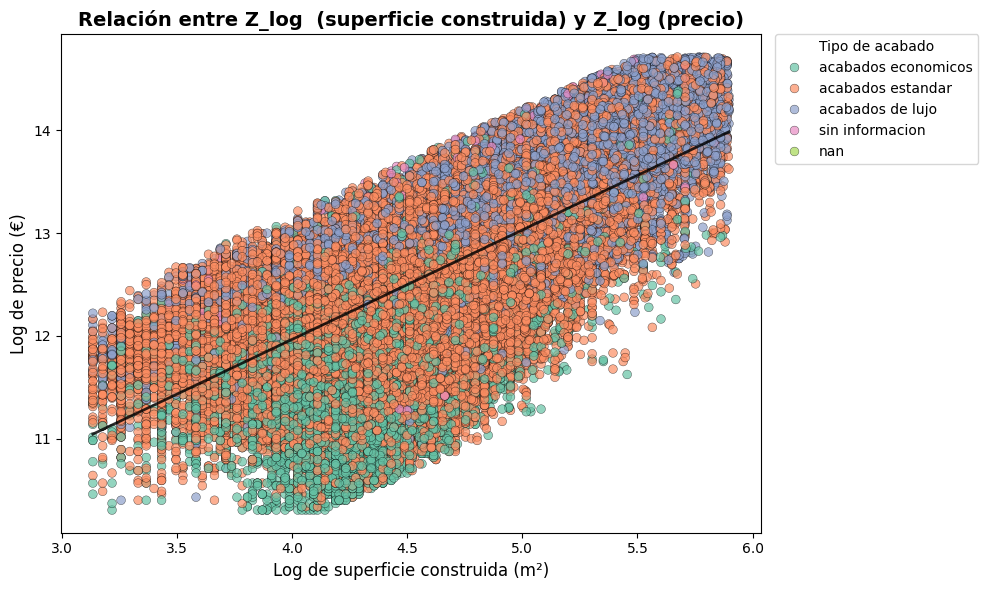

In [161]:


# print("="*150)
# print(" --> Graficas de dispersion [ Z_LOG_CONSTRUCTEDAREA, Z_LOG_PRICE ] con categorias [ bin_tipo_acabado ]")
# print("     aplicamos logaritmo para ver relacion clara entre valores y reducir el efecto de los outliers")
# print("="*150)
# print("\n")

md = """
---

➡️ Graficas de dispersion [ `Z_LOG_CONSTRUCTEDAREA , Z_LOG_PRICE`]  con categorias [ `bin_tipo_acabado` ]
   Aplicamos logaritmo para ver relacion clara entre valores y reducir el efecto de los outliers

---
"""
display(Markdown(md))
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
                data = df_idealista_limpio,
                x = "Z_LOG_CONSTRUCTEDAREA",
                y = "Z_LOG_PRICE",
                hue = "bin_tipo_acabado",
                palette = "Set2",
                alpha = 0.7,
                s = 40,
                edgecolor = "black",
                linewidth = 0.3,
                ax = ax
               )

# Línea de tendencia global
sns.regplot(
            data = df_idealista_limpio,
            x = "Z_LOG_CONSTRUCTEDAREA",
            y = "LOG_PRICE",
            scatter = False,
            color = "black",
            line_kws = {"linewidth": 2, "alpha": 0.8},
            ax = ax
  )

ax.set_title("Relación entre Z_log  (superficie construida) y Z_log (precio)", fontsize=14, fontweight="bold")
ax.set_xlabel("Log de superficie construida (m²)", fontsize=12)
ax.set_ylabel("Log de precio (€)", fontsize=12)

handles, labels = ax.get_legend_handles_labels()
ax.legend(
          title = "Tipo de acabado",
          bbox_to_anchor = (1.02, 1),
          loc = "upper left",
          borderaxespad = 0.
         ) 

plt.tight_layout()
plt.show()

In [ ]:
# Volvemos a mostrar un resumen del dataset limpio para ver como ha quedado.
df_resumen_limpio: pd.DataFrame = mostrar_resumen_info(df_idealista_limpio)
df_resumen_limpio

In [ ]:
# Exportar el dataset a un xlsx para ver el contenido .
try:
    df_idealista_limpio.to_excel("Idealista/Xlsx/idealista_completo_limpio.xlsx", index=False) # index=False para no incluir la columna de indices en el archivo exportado.   
    print("Archivo exportado exitosamente a Idealista/Xlsx/idealista_completo_limpio.xlsx")
except Exception as e:
    print(f"Error al exportar el archivo: {e}") 


---

➡️ Guardamos el dataset para la Fase 2 `df_idealista_limpio.csv`

---

In [ ]:
# Despues de todo el analisis y limpieza de datos, guardamos da_idealista_limpio en un CSV para la fase 2.
 
df_idealista_limpio.to_csv("Idealista/df_idealista_limpio.csv", index = False)

## Entrega y Requisitos Técnicos

La entrega se realizará mediante el envío de un enlace a un repositorio público (GitHub, GitLab, BitBucket, Codeberg o similar) que cumpla con las siguientes condiciones:

*   **Estructura de Notebooks:** Todos los cuadernos de Jupyter deben estar organizados y, preferiblemente, numerados según el orden lógico de ejecución (ej. `01_limpieza_eda.ipynb`, `02_modelado_estadistico.ipynb`). El código debe estar debidamente comentado e, idealmente, con anotaciones de tipado de datos.
*   **Documentación:** El repositorio debe incluir un archivo `README.md` que explique el contexto del dataset, las preguntas de investigación planteadas y un resumen de las conclusiones alcanzadas.
*   **Uso de Git:** Es imprescindible el uso correcto del archivo `.gitignore` para evitar la subida de archivos irrelevantes (entornos virtuales, archivos temporales del sistema, etc.).